In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
from tensorflow.keras.layers import Dense, Flatten, Input, Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.models import Sequential
from glob import glob
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

In [3]:
#import splitfolders # or import splitfolders
#input_folder = "plantvillage"
#output = "output/plantvillage" #where you want the split datasets saved. one will be created if it does not exist or none is set

#splitfolders.ratio(input_folder, output=output, seed=42, ratio=(.7, .3,)) # ratio of split are in order of train/val/test. You can change to whatever you want. For train/val sets only, you could do .75, .25 for example.

Copying files: 17572 files [00:34, 507.51 files/s]


In [20]:
train_path = "plantvillagenew1/train"
test_path = "plantvillagenew1/val"

In [21]:
IMAGE_SIZE = [128,128]

In [22]:
# Scaling all the images between 0 to 1

train_datagen = ImageDataGenerator(rescale = 1./255, shear_range=0.2, zoom_range=0.2, horizontal_flip=False)

# Performing only scaling on the test dataset

test_datagen = ImageDataGenerator(rescale=1./255)

In [23]:
train_set = train_datagen.flow_from_directory(train_path,
                                              target_size=(128,128),
                                              batch_size=16,
                                              class_mode = 'categorical')

test_set = test_datagen.flow_from_directory(test_path,
                                            target_size=(128,128),
                                            batch_size=16,
                                            class_mode='categorical')

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


In [8]:
from keras import backend as K

def recall_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    recall = true_positives / (possible_positives + K.epsilon())
    return recall

def precision_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision

def f1_m(y_true, y_pred):
    precision = precision_m(y_true, y_pred)
    recall = recall_m(y_true, y_pred)
    return 2*((precision*recall)/(precision+recall+K.epsilon()))

In [9]:
from keras.metrics import Precision, Recall
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Sequential, Model

learning_rate_reduction = ReduceLROnPlateau(
    monitor="val_accuracy", patience=3, verbose=1, factor=0.3, min_lr=0.0000001
)
early_stop = EarlyStopping(
    patience=10,
    verbose=1,
    monitor="val_accuracy",
    mode="max",
    min_delta=0.001,
    restore_best_weights=True,
)

In [10]:
ML_Model = []
accuracy = []
precision = []
recall = []
f1score = []

#function to call for storing the results
def storeResults(model, a,b,c,d):
    ML_Model.append(model)
    accuracy.append(round(a, 3))
    precision.append(round(b, 3))
    recall.append(round(c, 3))
    f1score.append(round(d, 3))

# AlexNet

In [11]:
from tensorflow.keras.layers import BatchNormalization

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout, Flatten, Conv2D, MaxPooling2D
#from keras.layers.normalization import BatchNormalization

In [13]:
np.random.seed(1000)

#Instantiation
AlexNet = Sequential()

#1st Convolutional Layer
AlexNet.add(Conv2D(filters=96, input_shape=(128,128,3), kernel_size=(11,11), strides=(4,4), padding='same'))
AlexNet.add(BatchNormalization())
AlexNet.add(Activation('relu'))
AlexNet.add(MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='same'))

#2nd Convolutional Layer
AlexNet.add(Conv2D(filters=256, kernel_size=(5, 5), strides=(1,1), padding='same'))
AlexNet.add(BatchNormalization())
AlexNet.add(Activation('relu'))
AlexNet.add(MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='same'))

#3rd Convolutional Layer
AlexNet.add(Conv2D(filters=384, kernel_size=(3,3), strides=(1,1), padding='same'))
AlexNet.add(BatchNormalization())
AlexNet.add(Activation('relu'))

#4th Convolutional Layer
AlexNet.add(Conv2D(filters=384, kernel_size=(3,3), strides=(1,1), padding='same'))
AlexNet.add(BatchNormalization())
AlexNet.add(Activation('relu'))

#5th Convolutional Layer
AlexNet.add(Conv2D(filters=256, kernel_size=(3,3), strides=(1,1), padding='same'))
AlexNet.add(BatchNormalization())
AlexNet.add(Activation('relu'))
AlexNet.add(MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='same'))

#Passing it to a Fully Connected layer
AlexNet.add(Flatten())
# 1st Fully Connected Layer
AlexNet.add(Dense(4096, input_shape=(32,32,3,)))
AlexNet.add(BatchNormalization())
AlexNet.add(Activation('relu'))
# Add Dropout to prevent overfitting
AlexNet.add(Dropout(0.4))

#2nd Fully Connected Layer
AlexNet.add(Dense(4096))
AlexNet.add(BatchNormalization())
AlexNet.add(Activation('relu'))
#Add Dropout
AlexNet.add(Dropout(0.4))

#3rd Fully Connected Layer
AlexNet.add(Dense(1000))
AlexNet.add(BatchNormalization())
AlexNet.add(Activation('relu'))
#Add Dropout
AlexNet.add(Dropout(0.4))

#Output Layer
AlexNet.add(Dense(38))
AlexNet.add(BatchNormalization())
AlexNet.add(Activation('softmax'))

#Model Summary
AlexNet.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 96)        34944     
                                                                 
 batch_normalization (BatchN  (None, 32, 32, 96)       384       
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 32, 32, 96)        0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 16, 16, 96)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 16, 16, 256)       614656    
                                                                 
 batch_normalization_1 (Batc  (None, 16, 16, 256)      1

In [14]:
AlexNet.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=["accuracy",f1_m,precision_m, recall_m])

In [15]:
hist2 = AlexNet.fit(train_set, validation_data=test_set, epochs=10, steps_per_epoch=len(train_set), validation_steps=len(test_set),callbacks=[learning_rate_reduction, early_stop])

Epoch 1/10
4394/4394 [==============================] - 391s 88ms/step - loss: 1.6464 - accuracy: 0.5436 - f1_m: 0.3384 - precision_m: 0.7056 - recall_m: 0.2426 - val_loss: 1.1921 - val_accuracy: 0.6744 - val_f1_m: 0.6754 - val_precision_m: 0.7525 - val_recall_m: 0.6166 - lr: 0.0010
Epoch 2/10
4394/4394 [==============================] - 190s 43ms/step - loss: 0.8570 - accuracy: 0.7688 - f1_m: 0.7304 - precision_m: 0.8761 - recall_m: 0.6352 - val_loss: 0.8938 - val_accuracy: 0.7500 - val_f1_m: 0.7558 - val_precision_m: 0.8414 - val_recall_m: 0.6902 - lr: 0.0010
Epoch 3/10
4394/4394 [==============================] - 187s 43ms/step - loss: 0.5581 - accuracy: 0.8506 - f1_m: 0.8372 - precision_m: 0.9071 - recall_m: 0.7815 - val_loss: 1.5270 - val_accuracy: 0.5924 - val_f1_m: 0.5892 - val_precision_m: 0.6767 - val_recall_m: 0.5256 - lr: 0.0010
Epoch 4/10
4394/4394 [==============================] - 191s 43ms/step - loss: 0.4072 - accuracy: 0.8901 - f1_m: 0.8834 - precision_m: 0.9265 - reca

In [16]:
AlexNet.save('alex.h5')

In [57]:
alex_acc = hist2.history["val_accuracy"][9]
alex_prec = hist2.history["val_precision_m"][9]
alex_rec = hist2.history["val_recall_m"][9]
alex_f1 = hist2.history["val_f1_m"][9]

In [58]:
storeResults('AlexNet',alex_acc,alex_prec,alex_rec,alex_f1)

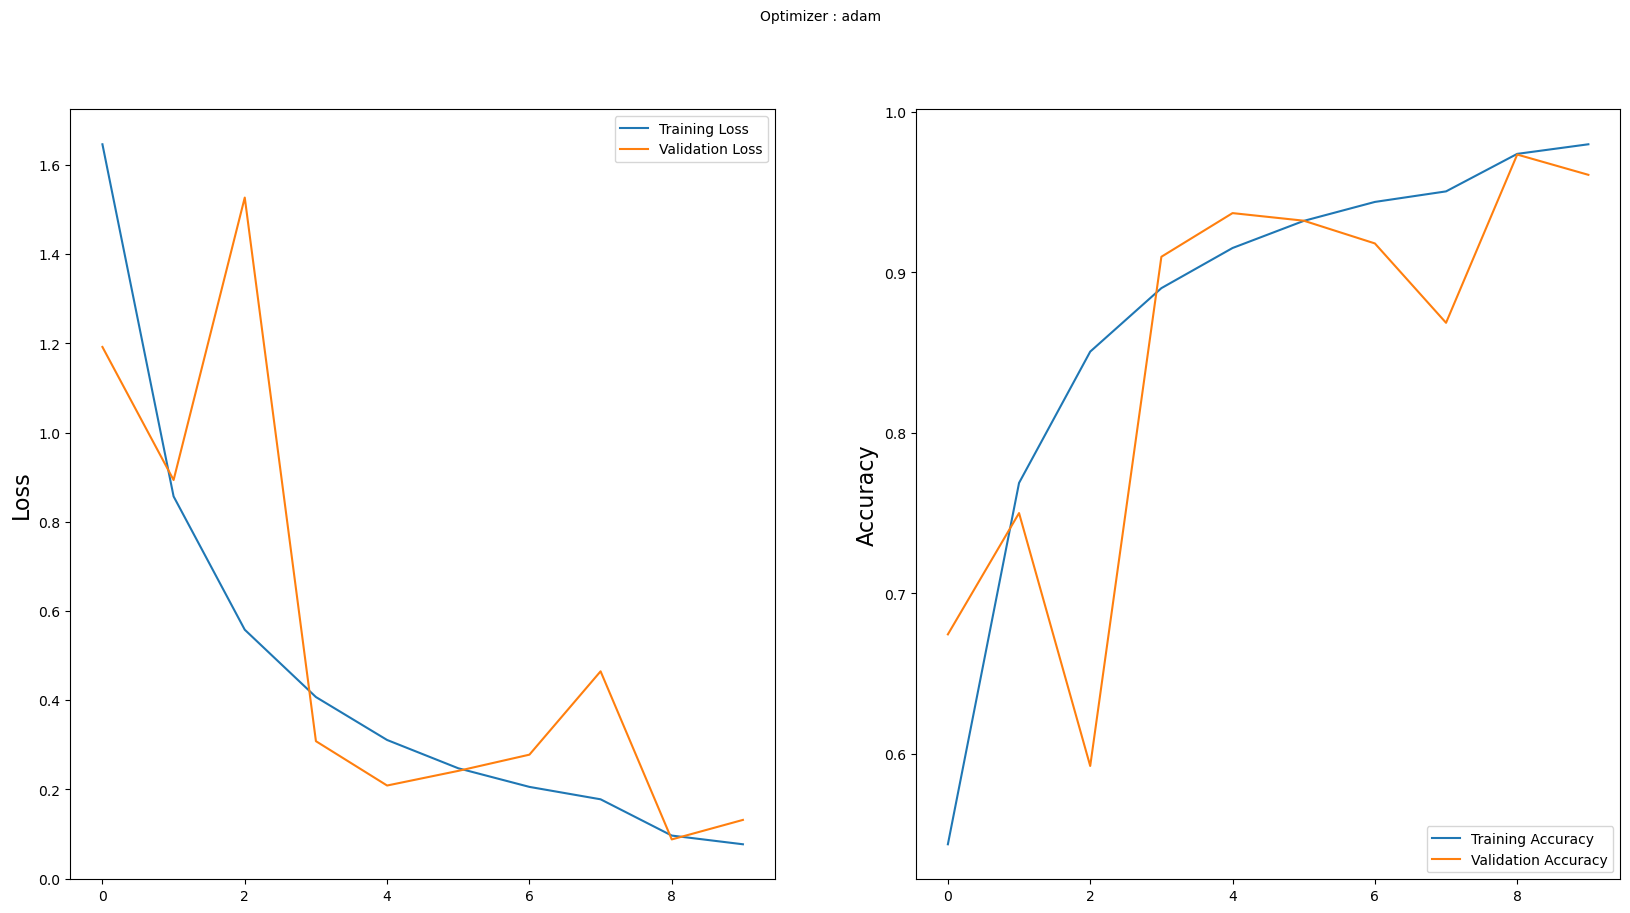

In [17]:
import matplotlib.pyplot as plt

x=hist2
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# ResNet

In [18]:
resnet = ResNet50(input_shape = IMAGE_SIZE + [3], weights='imagenet', include_top=False)

In [19]:
x = Flatten()(resnet.output)
prediction = Dense(38, activation='softmax')(x)
model3 = Model(inputs = resnet.inputs, outputs = prediction)
model3.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 134, 134, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 64, 64, 64)   9472        ['conv1_pad[0][0]']              
                                                                                                  
 conv1_bn (BatchNormalization)  (None, 64, 64, 64)   256         ['conv1_conv[0][0]']         

 conv2_block3_2_conv (Conv2D)   (None, 32, 32, 64)   36928       ['conv2_block3_1_relu[0][0]']    
                                                                                                  
 conv2_block3_2_bn (BatchNormal  (None, 32, 32, 64)  256         ['conv2_block3_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv2_block3_2_relu (Activatio  (None, 32, 32, 64)  0           ['conv2_block3_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv2_block3_3_conv (Conv2D)   (None, 32, 32, 256)  16640       ['conv2_block3_2_relu[0][0]']    
                                                                                                  
 conv2_blo

 conv3_block3_2_conv (Conv2D)   (None, 16, 16, 128)  147584      ['conv3_block3_1_relu[0][0]']    
                                                                                                  
 conv3_block3_2_bn (BatchNormal  (None, 16, 16, 128)  512        ['conv3_block3_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv3_block3_2_relu (Activatio  (None, 16, 16, 128)  0          ['conv3_block3_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv3_block3_3_conv (Conv2D)   (None, 16, 16, 512)  66048       ['conv3_block3_2_relu[0][0]']    
                                                                                                  
 conv3_blo

 conv4_block2_2_conv (Conv2D)   (None, 8, 8, 256)    590080      ['conv4_block2_1_relu[0][0]']    
                                                                                                  
 conv4_block2_2_bn (BatchNormal  (None, 8, 8, 256)   1024        ['conv4_block2_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv4_block2_2_relu (Activatio  (None, 8, 8, 256)   0           ['conv4_block2_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv4_block2_3_conv (Conv2D)   (None, 8, 8, 1024)   263168      ['conv4_block2_2_relu[0][0]']    
                                                                                                  
 conv4_blo

 conv4_block5_2_relu (Activatio  (None, 8, 8, 256)   0           ['conv4_block5_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv4_block5_3_conv (Conv2D)   (None, 8, 8, 1024)   263168      ['conv4_block5_2_relu[0][0]']    
                                                                                                  
 conv4_block5_3_bn (BatchNormal  (None, 8, 8, 1024)  4096        ['conv4_block5_3_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv4_block5_add (Add)         (None, 8, 8, 1024)   0           ['conv4_block4_out[0][0]',       
                                                                  'conv4_block5_3_bn[0][0]']      
          

 conv5_block2_2_relu (Activatio  (None, 4, 4, 512)   0           ['conv5_block2_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv5_block2_3_conv (Conv2D)   (None, 4, 4, 2048)   1050624     ['conv5_block2_2_relu[0][0]']    
                                                                                                  
 conv5_block2_3_bn (BatchNormal  (None, 4, 4, 2048)  8192        ['conv5_block2_3_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv5_block2_add (Add)         (None, 4, 4, 2048)   0           ['conv5_block1_out[0][0]',       
                                                                  'conv5_block2_3_bn[0][0]']      
          

In [20]:
model3.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=["accuracy",f1_m,precision_m, recall_m])

In [21]:
hist3 = model3.fit(train_set, validation_data=test_set, epochs=10, steps_per_epoch=len(train_set), validation_steps=len(test_set),callbacks=[learning_rate_reduction, early_stop])

Epoch 1/10
4394/4394 [==============================] - 195s 44ms/step - loss: 0.8991 - accuracy: 0.7680 - f1_m: 0.7653 - precision_m: 0.8129 - recall_m: 0.7296 - val_loss: 1.8013 - val_accuracy: 0.6266 - val_f1_m: 0.6277 - val_precision_m: 0.6543 - val_recall_m: 0.6047 - lr: 0.0010
Epoch 2/10
4394/4394 [==============================] - 197s 45ms/step - loss: 0.3620 - accuracy: 0.8891 - f1_m: 0.8910 - precision_m: 0.9063 - recall_m: 0.8771 - val_loss: 0.6577 - val_accuracy: 0.8289 - val_f1_m: 0.8314 - val_precision_m: 0.8514 - val_recall_m: 0.8135 - lr: 0.0010
Epoch 3/10
4394/4394 [==============================] - 196s 45ms/step - loss: 0.2698 - accuracy: 0.9173 - f1_m: 0.9183 - precision_m: 0.9273 - recall_m: 0.9099 - val_loss: 2.2966 - val_accuracy: 0.5746 - val_f1_m: 0.5808 - val_precision_m: 0.6080 - val_recall_m: 0.5576 - lr: 0.0010
Epoch 4/10
4394/4394 [==============================] - 195s 44ms/step - loss: 0.2134 - accuracy: 0.9342 - f1_m: 0.9353 - precision_m: 0.9412 - reca

In [22]:
model3.save('resnet.h5')

In [59]:
res_acc = hist3.history["val_accuracy"][9]
res_prec = hist3.history["val_precision_m"][9]
res_rec = hist3.history["val_recall_m"][9]
res_f1 = hist3.history["val_f1_m"][9]

In [60]:
storeResults('ResNet',res_acc,res_prec,res_rec,res_f1)

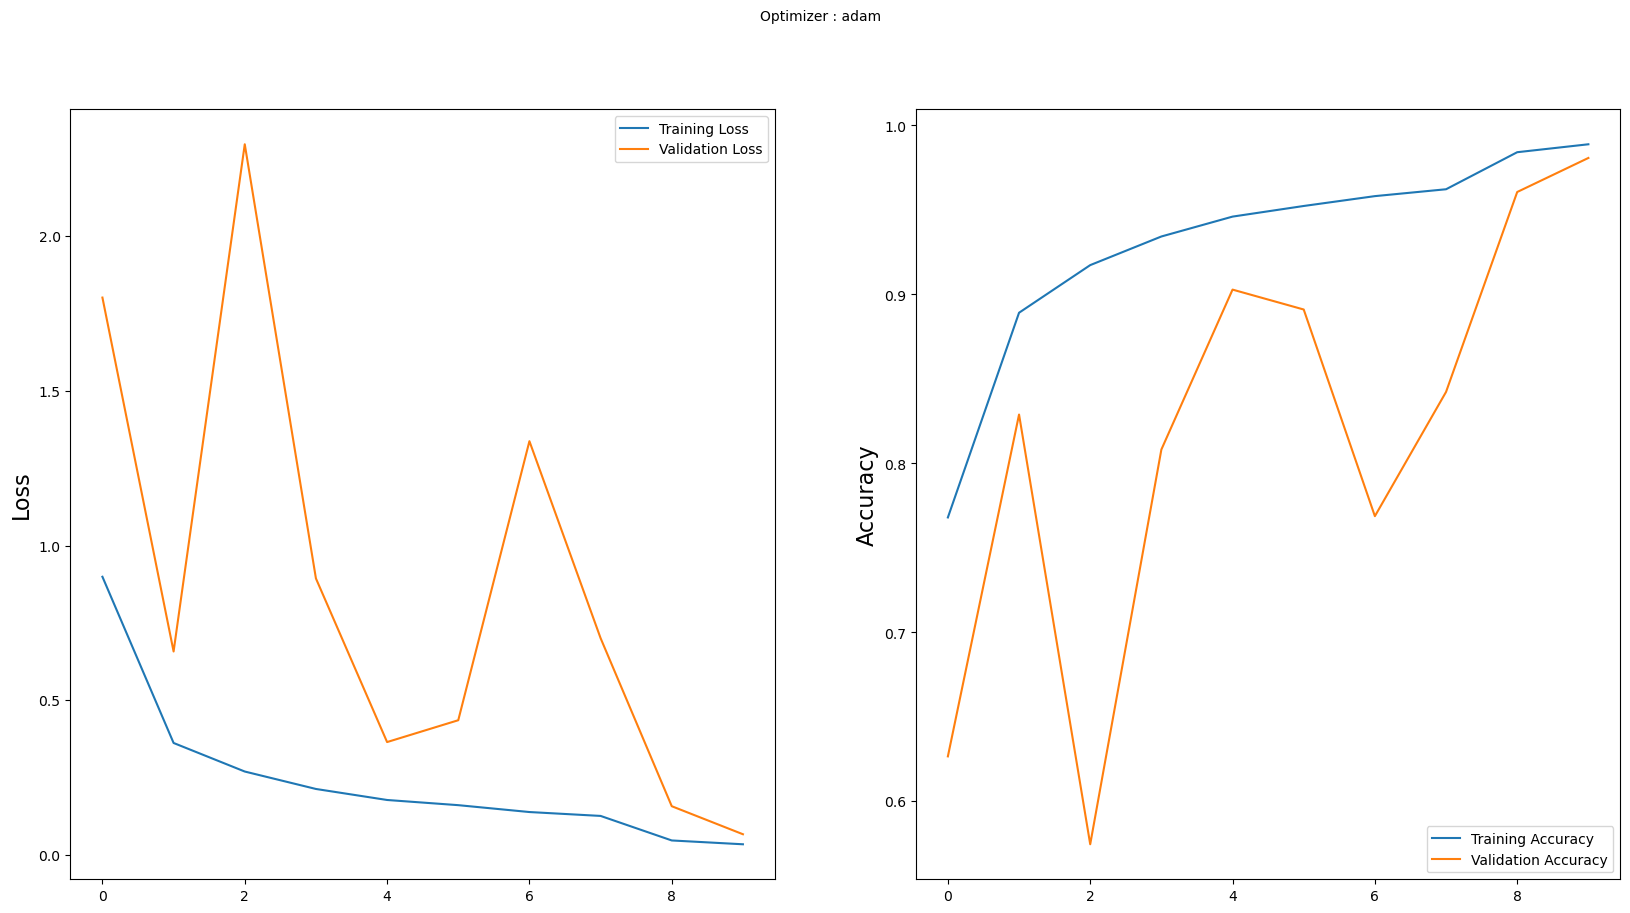

In [23]:
import matplotlib.pyplot as plt

x=hist3
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# TLMViT 

In [11]:
image_size = 128

In [12]:
from vit_keras import vit

In [13]:
import tensorflow_addons as tfa

In [14]:
vit_model = vit.vit_b16(
        image_size = image_size,
        activation = 'softmax',
        pretrained = True,
        include_top = False,
        pretrained_top = False,
        classes = 38)

In [15]:
model5 = tf.keras.Sequential([
        vit_model,
        tf.keras.layers.Flatten(),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(11, activation = tfa.activations.gelu),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dense(38, 'softmax')
    ],
    name = 'vision_transformer')

model5.summary()

Model: "vision_transformer"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vit-b16 (Functional)        (None, 768)               85697280  
                                                                 
 flatten (Flatten)           (None, 768)               0         
                                                                 
 batch_normalization (BatchN  (None, 768)              3072      
 ormalization)                                                   
                                                                 
 dense (Dense)               (None, 11)                8459      
                                                                 
 batch_normalization_1 (Batc  (None, 11)               44        
 hNormalization)                                                 
                                                                 
 dense_1 (Dense)             (None, 38)         

In [16]:
optimizer = tfa.optimizers.RectifiedAdam(learning_rate = 1e-4)

In [17]:
model5.compile(optimizer = optimizer, 
              loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing = 0.2), 
              metrics=["accuracy",f1_m,precision_m, recall_m])

In [31]:
hist5 = model5.fit(train_set, validation_data=test_set, epochs=10, steps_per_epoch=len(train_set), validation_steps=len(test_set),callbacks=[learning_rate_reduction, early_stop])

Epoch 1/10
4394/4394 [==============================] - 326s 72ms/step - loss: 2.2954 - accuracy: 0.7612 - f1_m: 0.0612 - precision_m: 0.2457 - recall_m: 0.0366 - val_loss: 1.6102 - val_accuracy: 0.9478 - val_f1_m: 0.7504 - val_precision_m: 0.9952 - val_recall_m: 0.6119 - lr: 1.0000e-04
Epoch 2/10
4394/4394 [==============================] - 315s 72ms/step - loss: 1.5570 - accuracy: 0.9566 - f1_m: 0.8276 - precision_m: 0.9884 - recall_m: 0.7438 - val_loss: 1.4172 - val_accuracy: 0.9781 - val_f1_m: 0.9769 - val_precision_m: 0.9872 - val_recall_m: 0.9675 - lr: 1.0000e-04
Epoch 3/10
4394/4394 [==============================] - 314s 71ms/step - loss: 1.4421 - accuracy: 0.9742 - f1_m: 0.9671 - precision_m: 0.9875 - recall_m: 0.9490 - val_loss: 1.3967 - val_accuracy: 0.9807 - val_f1_m: 0.9803 - val_precision_m: 0.9875 - val_recall_m: 0.9736 - lr: 1.0000e-04
Epoch 4/10
4394/4394 [==============================] - 314s 72ms/step - loss: 1.4173 - accuracy: 0.9785 - f1_m: 0.9736 - precision_m: 0

In [19]:
model5.save('vit.h5')

In [61]:
evit_acc = hist5.history["val_accuracy"][9]
evit_prec = hist5.history["val_precision_m"][9]
evit_rec = hist5.history["val_recall_m"][9]
evit_f1 = hist5.history["val_f1_m"][9]

In [62]:
storeResults('TLMViT',evit_acc,evit_prec,evit_rec,evit_f1)

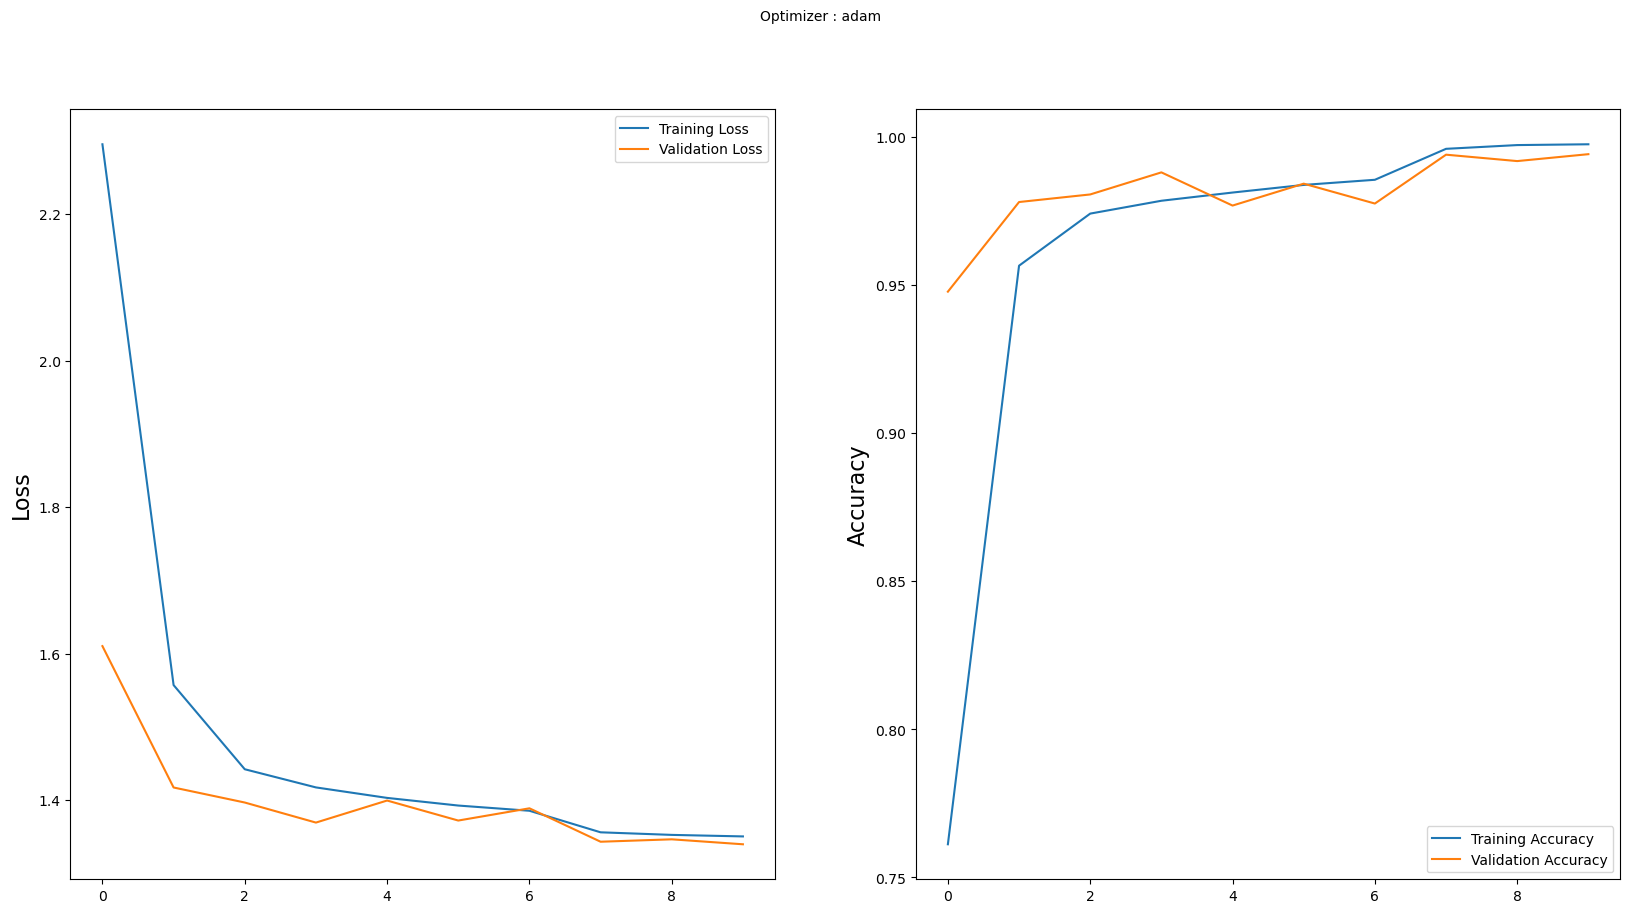

In [33]:
import matplotlib.pyplot as plt

x=hist5
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# VGG16

In [34]:
from tensorflow.keras.applications import VGG16, VGG19

In [35]:
des201=VGG16(input_shape = IMAGE_SIZE + [3], weights='imagenet', include_top=False)

In [36]:
x1= Flatten()(des201.output)
prediction1 = Dense(38, activation='softmax')(x1)
model6 = Model(inputs = des201.inputs, outputs = prediction1)
model6.summary()
model6.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=["accuracy",f1_m,precision_m, recall_m])

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 128, 128, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 128, 128, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 64, 64, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 64, 64, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 64, 64, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 32, 32, 128)       0   

In [37]:
hist6 = model6.fit(train_set, validation_data=test_set, epochs=10, steps_per_epoch=len(train_set), validation_steps=len(test_set))

Epoch 1/10
4394/4394 [==============================] - 191s 43ms/step - loss: 3.6398 - accuracy: 0.0277 - f1_m: 0.0000e+00 - precision_m: 0.0000e+00 - recall_m: 0.0000e+00 - val_loss: 3.6362 - val_accuracy: 0.0287 - val_f1_m: 0.0000e+00 - val_precision_m: 0.0000e+00 - val_recall_m: 0.0000e+00
Epoch 2/10
4394/4394 [==============================] - 191s 44ms/step - loss: 3.6366 - accuracy: 0.0279 - f1_m: 0.0000e+00 - precision_m: 0.0000e+00 - recall_m: 0.0000e+00 - val_loss: 3.6361 - val_accuracy: 0.0287 - val_f1_m: 0.0000e+00 - val_precision_m: 0.0000e+00 - val_recall_m: 0.0000e+00
Epoch 3/10
4394/4394 [==============================] - 192s 44ms/step - loss: 3.6366 - accuracy: 0.0274 - f1_m: 0.0000e+00 - precision_m: 0.0000e+00 - recall_m: 0.0000e+00 - val_loss: 3.6361 - val_accuracy: 0.0287 - val_f1_m: 0.0000e+00 - val_precision_m: 0.0000e+00 - val_recall_m: 0.0000e+00
Epoch 4/10
4394/4394 [==============================] - 188s 43ms/step - loss: 3.6366 - accuracy: 0.0278 - f1_m: 0.

In [63]:
evit_acc = hist6.history["val_accuracy"][9]
evit_prec = hist6.history["val_precision_m"][9]
evit_rec = hist6.history["val_recall_m"][9]
evit_f1 = hist6.history["val_f1_m"][9]

storeResults('VGG16',evit_acc,evit_prec,evit_rec,evit_f1)

In [64]:
model6.save('vgg16.h5')

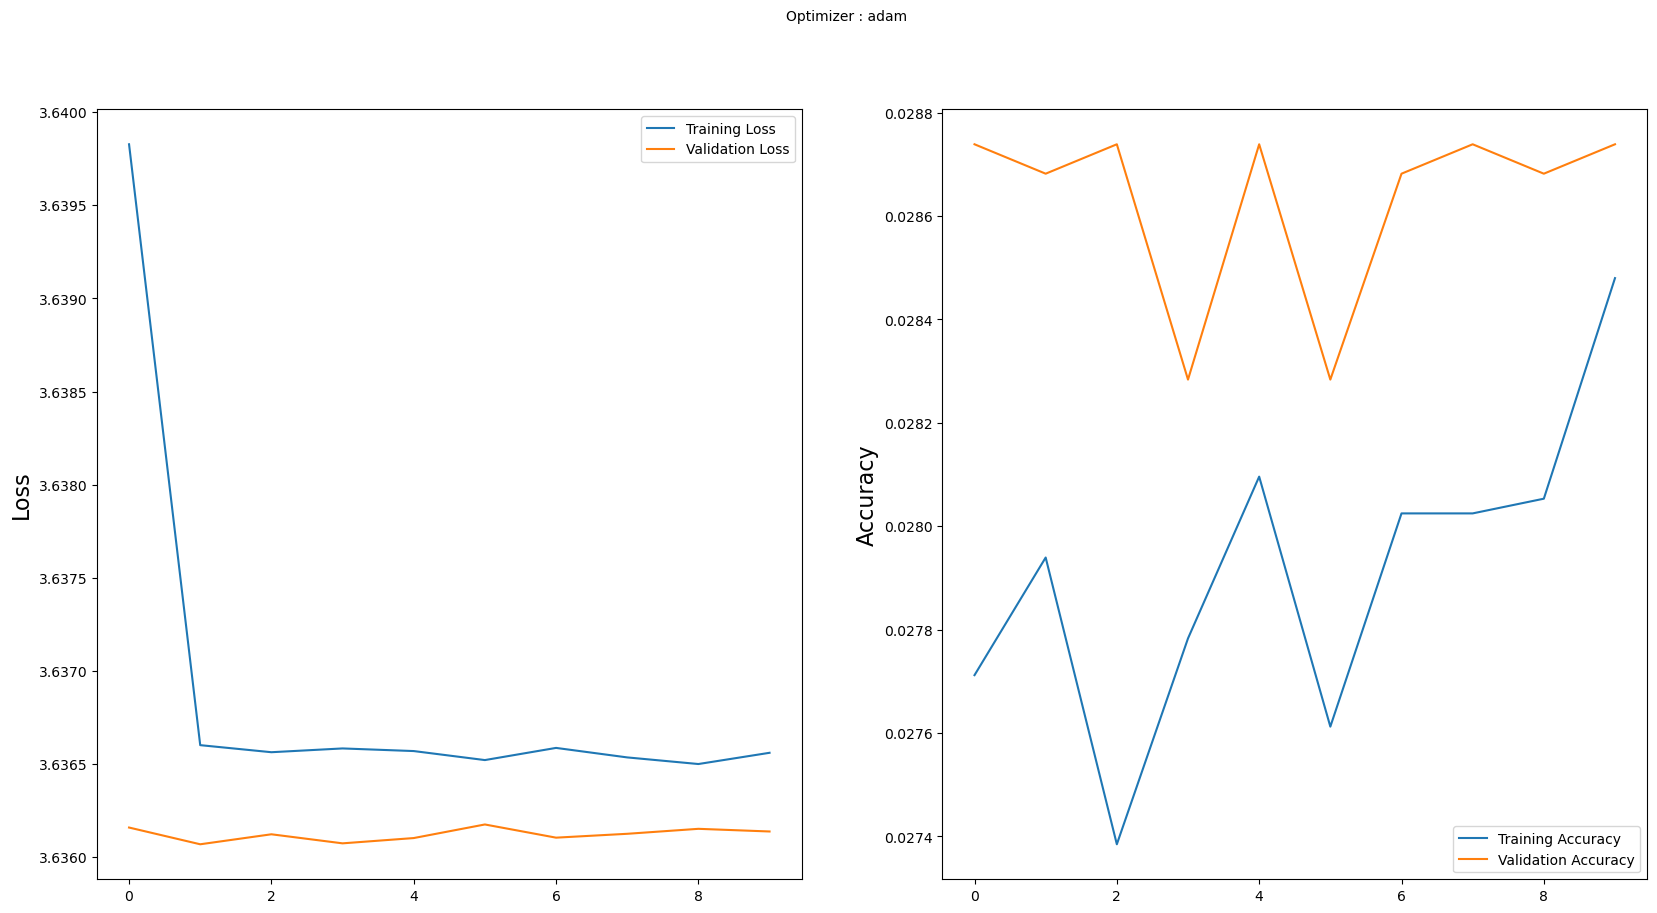

In [39]:
import matplotlib.pyplot as plt

x=hist6
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# VGG19

In [40]:
des201=VGG19(input_shape = IMAGE_SIZE + [3], weights='imagenet', include_top=False)

x1= Flatten()(des201.output)
prediction1 = Dense(38, activation='softmax')(x1)
model7 = Model(inputs = des201.inputs, outputs = prediction1)
model7.summary()
model7.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=["accuracy",f1_m,precision_m, recall_m])

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 128, 128, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 128, 128, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 64, 64, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 64, 64, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 64, 64, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 32, 32, 128)       0   

In [41]:
hist7 = model7.fit(train_set, validation_data=test_set, epochs=10, steps_per_epoch=len(train_set), validation_steps=len(test_set))

Epoch 1/10
4394/4394 [==============================] - 191s 43ms/step - loss: 3.6382 - accuracy: 0.0271 - f1_m: 0.0000e+00 - precision_m: 0.0000e+00 - recall_m: 0.0000e+00 - val_loss: 3.6363 - val_accuracy: 0.0287 - val_f1_m: 0.0000e+00 - val_precision_m: 0.0000e+00 - val_recall_m: 0.0000e+00
Epoch 2/10
4394/4394 [==============================] - 190s 43ms/step - loss: 3.6366 - accuracy: 0.0272 - f1_m: 0.0000e+00 - precision_m: 0.0000e+00 - recall_m: 0.0000e+00 - val_loss: 3.6361 - val_accuracy: 0.0287 - val_f1_m: 0.0000e+00 - val_precision_m: 0.0000e+00 - val_recall_m: 0.0000e+00
Epoch 3/10
4394/4394 [==============================] - 186s 42ms/step - loss: 3.6365 - accuracy: 0.0282 - f1_m: 0.0000e+00 - precision_m: 0.0000e+00 - recall_m: 0.0000e+00 - val_loss: 3.6362 - val_accuracy: 0.0287 - val_f1_m: 0.0000e+00 - val_precision_m: 0.0000e+00 - val_recall_m: 0.0000e+00
Epoch 4/10
4394/4394 [==============================] - 191s 43ms/step - loss: 3.6365 - accuracy: 0.0287 - f1_m: 0.

In [65]:
evit_acc = hist7.history["val_accuracy"][9]
evit_prec = hist7.history["val_precision_m"][9]
evit_rec = hist7.history["val_recall_m"][9]
evit_f1 = hist7.history["val_f1_m"][9]

storeResults('VGG19',evit_acc,evit_prec,evit_rec,evit_f1)

In [66]:
model7.save('vgg19.h5')

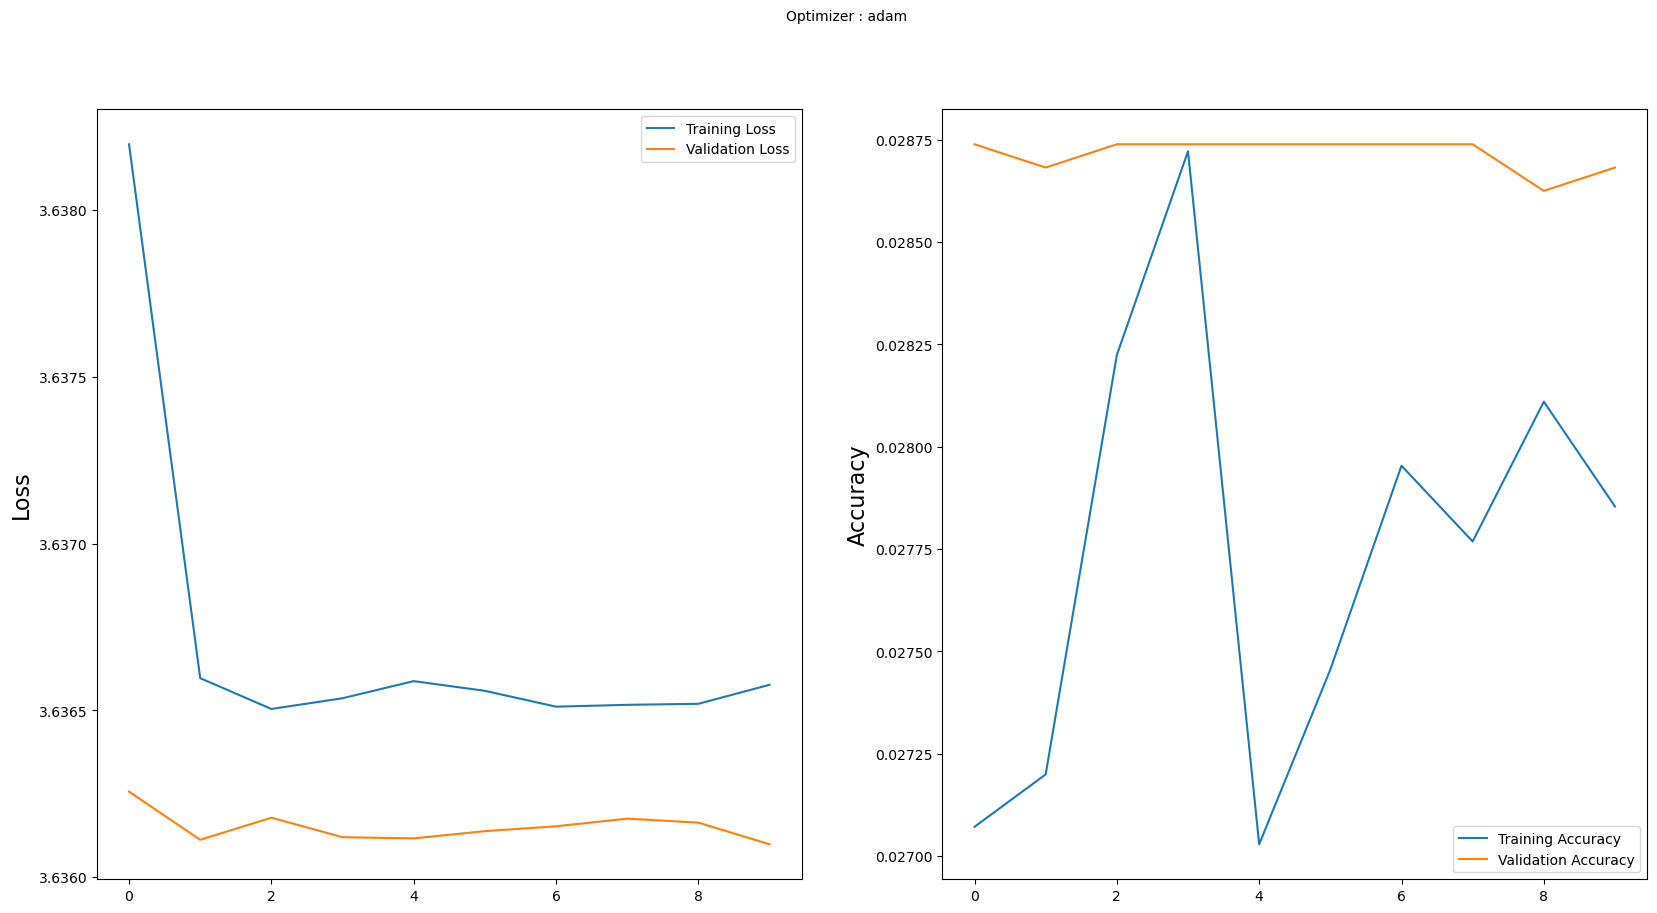

In [43]:
import matplotlib.pyplot as plt

x=hist7
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# Xception

In [44]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.optimizers import Adam

In [45]:
# Defining the pretrained base model
base = Xception(include_top=False, weights='imagenet', input_shape=(128,128,3))
x = base.output
x = GlobalAveragePooling2D()(x)
# Defining the head of the model where the prediction is conducted
head = Dense(38, activation='softmax')(x)
# Combining base and head 
model8 = Model(inputs=base.input, outputs=head)

model8.compile(optimizer='sgd', 
              loss = 'categorical_crossentropy', 
              metrics=["accuracy",f1_m,precision_m, recall_m])

model8.summary()

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_5 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 block1_conv1 (Conv2D)          (None, 63, 63, 32)   864         ['input_5[0][0]']                
                                                                                                  
 block1_conv1_bn (BatchNormaliz  (None, 63, 63, 32)  128         ['block1_conv1[0][0]']           
 ation)                                                                                           
                                                                                            

 n)                                                                                               
                                                                                                  
 block4_sepconv2 (SeparableConv  (None, 16, 16, 728)  536536     ['block4_sepconv2_act[0][0]']    
 2D)                                                                                              
                                                                                                  
 block4_sepconv2_bn (BatchNorma  (None, 16, 16, 728)  2912       ['block4_sepconv2[0][0]']        
 lization)                                                                                        
                                                                                                  
 conv2d_7 (Conv2D)              (None, 8, 8, 728)    186368      ['add_1[0][0]']                  
                                                                                                  
 block4_po

                                                                                                  
 block7_sepconv1_bn (BatchNorma  (None, 8, 8, 728)   2912        ['block7_sepconv1[0][0]']        
 lization)                                                                                        
                                                                                                  
 block7_sepconv2_act (Activatio  (None, 8, 8, 728)   0           ['block7_sepconv1_bn[0][0]']     
 n)                                                                                               
                                                                                                  
 block7_sepconv2 (SeparableConv  (None, 8, 8, 728)   536536      ['block7_sepconv2_act[0][0]']    
 2D)                                                                                              
                                                                                                  
 block7_se

                                                                  'add_6[0][0]']                  
                                                                                                  
 block10_sepconv1_act (Activati  (None, 8, 8, 728)   0           ['add_7[0][0]']                  
 on)                                                                                              
                                                                                                  
 block10_sepconv1 (SeparableCon  (None, 8, 8, 728)   536536      ['block10_sepconv1_act[0][0]']   
 v2D)                                                                                             
                                                                                                  
 block10_sepconv1_bn (BatchNorm  (None, 8, 8, 728)   2912        ['block10_sepconv1[0][0]']       
 alization)                                                                                       
          

 block12_sepconv3 (SeparableCon  (None, 8, 8, 728)   536536      ['block12_sepconv3_act[0][0]']   
 v2D)                                                                                             
                                                                                                  
 block12_sepconv3_bn (BatchNorm  (None, 8, 8, 728)   2912        ['block12_sepconv3[0][0]']       
 alization)                                                                                       
                                                                                                  
 add_10 (Add)                   (None, 8, 8, 728)    0           ['block12_sepconv3_bn[0][0]',    
                                                                  'add_9[0][0]']                  
                                                                                                  
 block13_sepconv1_act (Activati  (None, 8, 8, 728)   0           ['add_10[0][0]']                 
 on)      

In [46]:
hist8 = model8.fit(train_set, validation_data=test_set, epochs=10, steps_per_epoch=len(train_set), validation_steps=len(test_set))

Epoch 1/10
4394/4394 [==============================] - 327s 74ms/step - loss: 0.6340 - accuracy: 0.8438 - f1_m: 0.7953 - precision_m: 0.8977 - recall_m: 0.7475 - val_loss: 0.0945 - val_accuracy: 0.9725 - val_f1_m: 0.9708 - val_precision_m: 0.9793 - val_recall_m: 0.9629
Epoch 2/10
4394/4394 [==============================] - 194s 44ms/step - loss: 0.1139 - accuracy: 0.9672 - f1_m: 0.9662 - precision_m: 0.9761 - recall_m: 0.9573 - val_loss: 0.0549 - val_accuracy: 0.9824 - val_f1_m: 0.9821 - val_precision_m: 0.9853 - val_recall_m: 0.9792
Epoch 3/10
4394/4394 [==============================] - 193s 44ms/step - loss: 0.0702 - accuracy: 0.9800 - f1_m: 0.9793 - precision_m: 0.9839 - recall_m: 0.9750 - val_loss: 0.0448 - val_accuracy: 0.9880 - val_f1_m: 0.9853 - val_precision_m: 0.9899 - val_recall_m: 0.9810
Epoch 4/10
4394/4394 [==============================] - 193s 44ms/step - loss: 0.0479 - accuracy: 0.9856 - f1_m: 0.9856 - precision_m: 0.9887 - recall_m: 0.9827 - val_loss: 0.0292 - val_a

In [67]:
xce_acc = hist8.history["val_accuracy"][9]
xce_prec = hist8.history["val_precision_m"][9]
xce_rec = hist8.history["val_recall_m"][9]
xce_f1 = hist8.history["val_f1_m"][9]

storeResults('Xception',xce_acc,xce_prec,xce_rec,xce_f1)

In [47]:
model8.save('xce.h5')

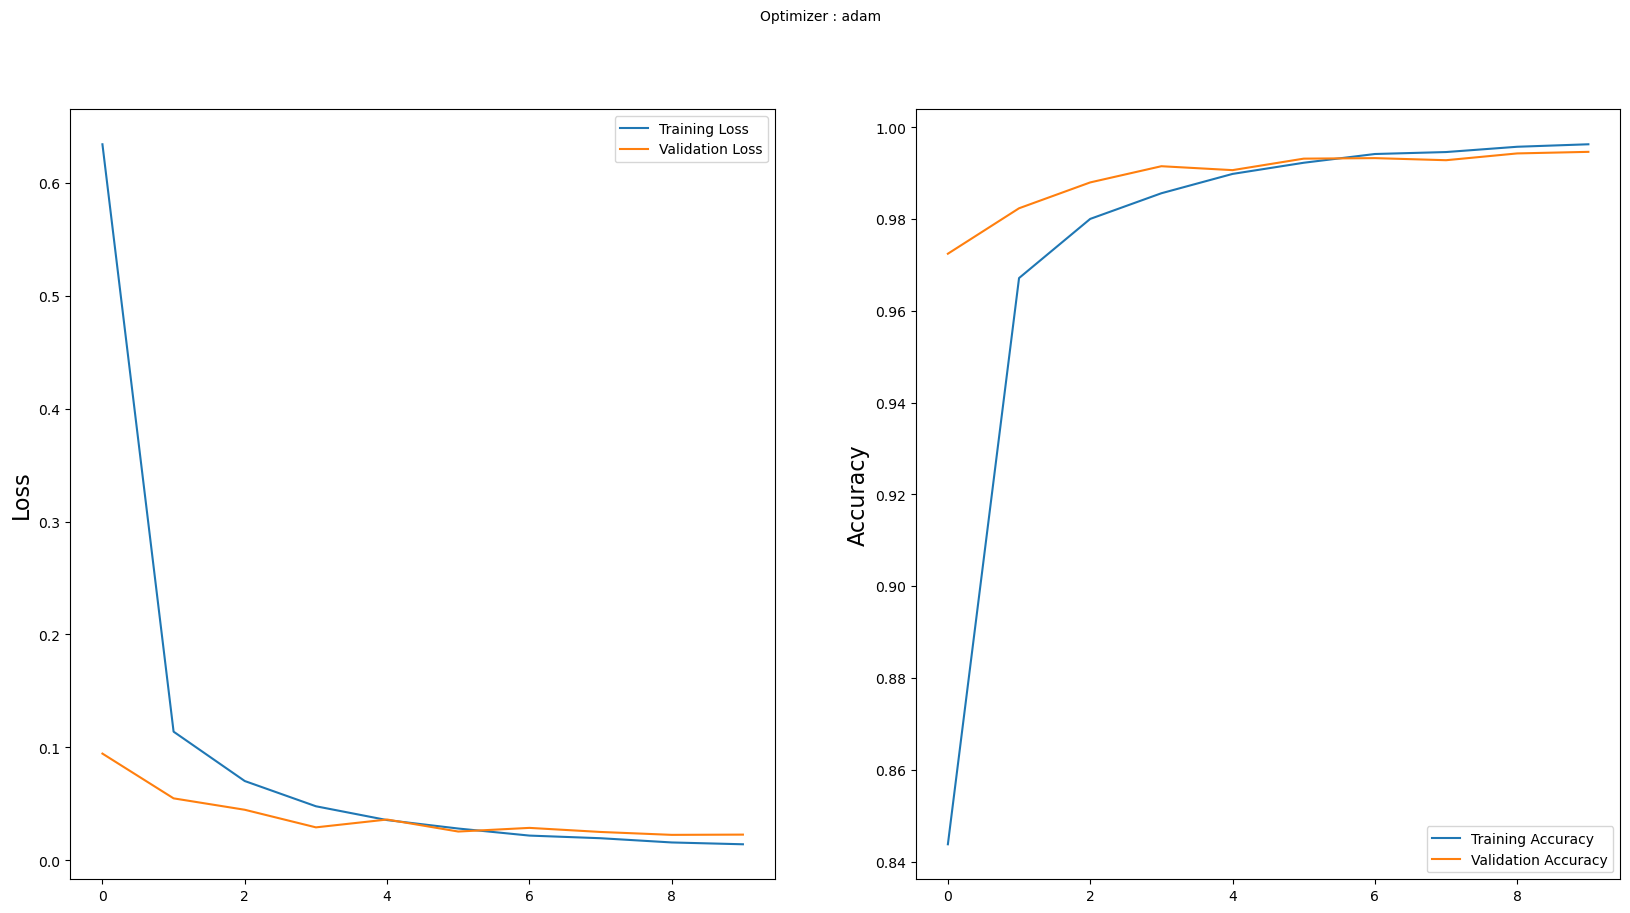

In [48]:
import matplotlib.pyplot as plt

x=hist8
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# InceptionV3

In [49]:
from tensorflow.keras.callbacks import ModelCheckpoint
#from keras.models import load_model
from tensorflow.keras.utils import plot_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img

In [50]:
# create the base pre-trained model
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
base_model = InceptionV3(weights='imagenet', include_top=False)

# add a global spatial average pooling layer
x2 = base_model.output
x2 = GlobalAveragePooling2D()(x2)

In [51]:
predictions = Dense(38, activation='softmax')(x2)

# this is the model we will train
model9 = Model(inputs=base_model.input, outputs=predictions)
model9.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=["accuracy",f1_m,precision_m, recall_m])
model9.summary()

Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_6 (InputLayer)           [(None, None, None,  0           []                               
                                 3)]                                                              
                                                                                                  
 conv2d_9 (Conv2D)              (None, None, None,   864         ['input_6[0][0]']                
                                32)                                                               
                                                                                                  
 batch_normalization_15 (BatchN  (None, None, None,   96         ['conv2d_9[0][0]']               
 ormalization)                  32)                                                         

                                                                                                  
 average_pooling2d (AveragePool  (None, None, None,   0          ['max_pooling2d_4[0][0]']        
 ing2D)                         192)                                                              
                                                                                                  
 conv2d_14 (Conv2D)             (None, None, None,   12288       ['max_pooling2d_4[0][0]']        
                                64)                                                               
                                                                                                  
 conv2d_16 (Conv2D)             (None, None, None,   76800       ['activation_15[0][0]']          
                                64)                                                               
                                                                                                  
 conv2d_19

                                                                                                  
 conv2d_27 (Conv2D)             (None, None, None,   16384       ['average_pooling2d_1[0][0]']    
                                64)                                                               
                                                                                                  
 batch_normalization_27 (BatchN  (None, None, None,   192        ['conv2d_21[0][0]']              
 ormalization)                  64)                                                               
                                                                                                  
 batch_normalization_29 (BatchN  (None, None, None,   192        ['conv2d_23[0][0]']              
 ormalization)                  64)                                                               
                                                                                                  
 batch_nor

                                                                                                  
 batch_normalization_40 (BatchN  (None, None, None,   192        ['conv2d_34[0][0]']              
 ormalization)                  64)                                                               
                                                                                                  
 activation_28 (Activation)     (None, None, None,   0           ['batch_normalization_34[0][0]'] 
                                64)                                                               
                                                                                                  
 activation_30 (Activation)     (None, None, None,   0           ['batch_normalization_36[0][0]'] 
                                64)                                                               
                                                                                                  
 activatio

                                128)                                                              
                                                                                                  
 conv2d_45 (Conv2D)             (None, None, None,   114688      ['activation_44[0][0]']          
                                128)                                                              
                                                                                                  
 batch_normalization_46 (BatchN  (None, None, None,   384        ['conv2d_40[0][0]']              
 ormalization)                  128)                                                              
                                                                                                  
 batch_normalization_51 (BatchN  (None, None, None,   384        ['conv2d_45[0][0]']              
 ormalization)                  128)                                                              
          

...

 batch_normalization_68 (BatchN  (None, None, None,   576        ['conv2d_62[0][0]']              
 ormalization)                  192)                                                              
                                                                                                  
 batch_normalization_73 (BatchN  (None, None, None,   576        ['conv2d_67[0][0]']              
 ormalization)                  192)                                                              
                                                                                                  
 batch_normalization_74 (BatchN  (None, None, None,   576        ['conv2d_68[0][0]']              
 ormalization)                  192)                                                              
                                                                                                  
 activation_59 (Activation)     (None, None, None,   0           ['batch_normalization_65[0][0]'] 
          

 conv2d_69 (Conv2D)             (None, None, None,   147456      ['mixed6[0][0]']                 
                                192)                                                              
                                                                                                  
 conv2d_72 (Conv2D)             (None, None, None,   258048      ['activation_71[0][0]']          
                                192)                                                              
                                                                                                  
 conv2d_77 (Conv2D)             (None, None, None,   258048      ['activation_76[0][0]']          
                                192)                                                              
                                                                                                  
 conv2d_78 (Conv2D)             (None, None, None,   147456      ['average_pooling2d_6[0][0]']    
          

 batch_normalization_86 (BatchN  (None, None, None,   960        ['conv2d_80[0][0]']              
 ormalization)                  320)                                                              
                                                                                                  
 batch_normalization_90 (BatchN  (None, None, None,   576        ['conv2d_84[0][0]']              
 ormalization)                  192)                                                              
                                                                                                  
 activation_80 (Activation)     (None, None, None,   0           ['batch_normalization_86[0][0]'] 
                                320)                                                              
                                                                                                  
 activation_84 (Activation)     (None, None, None,   0           ['batch_normalization_90[0][0]'] 
          

                                384)                                                              
                                                                                                  
 activation_88 (Activation)     (None, None, None,   0           ['batch_normalization_94[0][0]'] 
                                384)                                                              
                                                                                                  
 activation_91 (Activation)     (None, None, None,   0           ['batch_normalization_97[0][0]'] 
                                384)                                                              
                                                                                                  
 activation_92 (Activation)     (None, None, None,   0           ['batch_normalization_98[0][0]'] 
                                384)                                                              
          

 Normalization)                 384)                                                              
                                                                                                  
 batch_normalization_107 (Batch  (None, None, None,   1152       ['conv2d_101[0][0]']             
 Normalization)                 384)                                                              
                                                                                                  
 conv2d_102 (Conv2D)            (None, None, None,   393216      ['average_pooling2d_8[0][0]']    
                                192)                                                              
                                                                                                  
 batch_normalization_100 (Batch  (None, None, None,   960        ['conv2d_94[0][0]']              
 Normalization)                 320)                                                              
          

In [52]:
hist9 = model9.fit(train_set, validation_data=test_set, epochs=10, steps_per_epoch=len(train_set), validation_steps=len(test_set),callbacks=[learning_rate_reduction, early_stop])

Epoch 1/10
4394/4394 [==============================] - 196s 44ms/step - loss: 0.7386 - accuracy: 0.7789 - f1_m: 0.7696 - precision_m: 0.8446 - recall_m: 0.7206 - val_loss: 0.4131 - val_accuracy: 0.8681 - val_f1_m: 0.8693 - val_precision_m: 0.8862 - val_recall_m: 0.8540 - lr: 0.0010
Epoch 2/10
4394/4394 [==============================] - 196s 45ms/step - loss: 0.2938 - accuracy: 0.9071 - f1_m: 0.9076 - precision_m: 0.9264 - recall_m: 0.8907 - val_loss: 0.2481 - val_accuracy: 0.9261 - val_f1_m: 0.9270 - val_precision_m: 0.9359 - val_recall_m: 0.9188 - lr: 0.0010
Epoch 3/10
4394/4394 [==============================] - 192s 44ms/step - loss: 0.2089 - accuracy: 0.9319 - f1_m: 0.9325 - precision_m: 0.9430 - recall_m: 0.9229 - val_loss: 1.1239 - val_accuracy: 0.7510 - val_f1_m: 0.7556 - val_precision_m: 0.7761 - val_recall_m: 0.7374 - lr: 0.0010
Epoch 4/10
4394/4394 [==============================] - 196s 45ms/step - loss: 0.1562 - accuracy: 0.9502 - f1_m: 0.9503 - precision_m: 0.9575 - reca

In [68]:
inc_acc = hist9.history["val_accuracy"][9]
inc_prec = hist9.history["val_precision_m"][9]
inc_rec = hist9.history["val_recall_m"][9]
inc_f1 = hist9.history["val_f1_m"][9]

storeResults('InceptionV3',inc_acc,inc_prec,inc_rec,inc_f1)

In [53]:
model9.save('incep.h5')

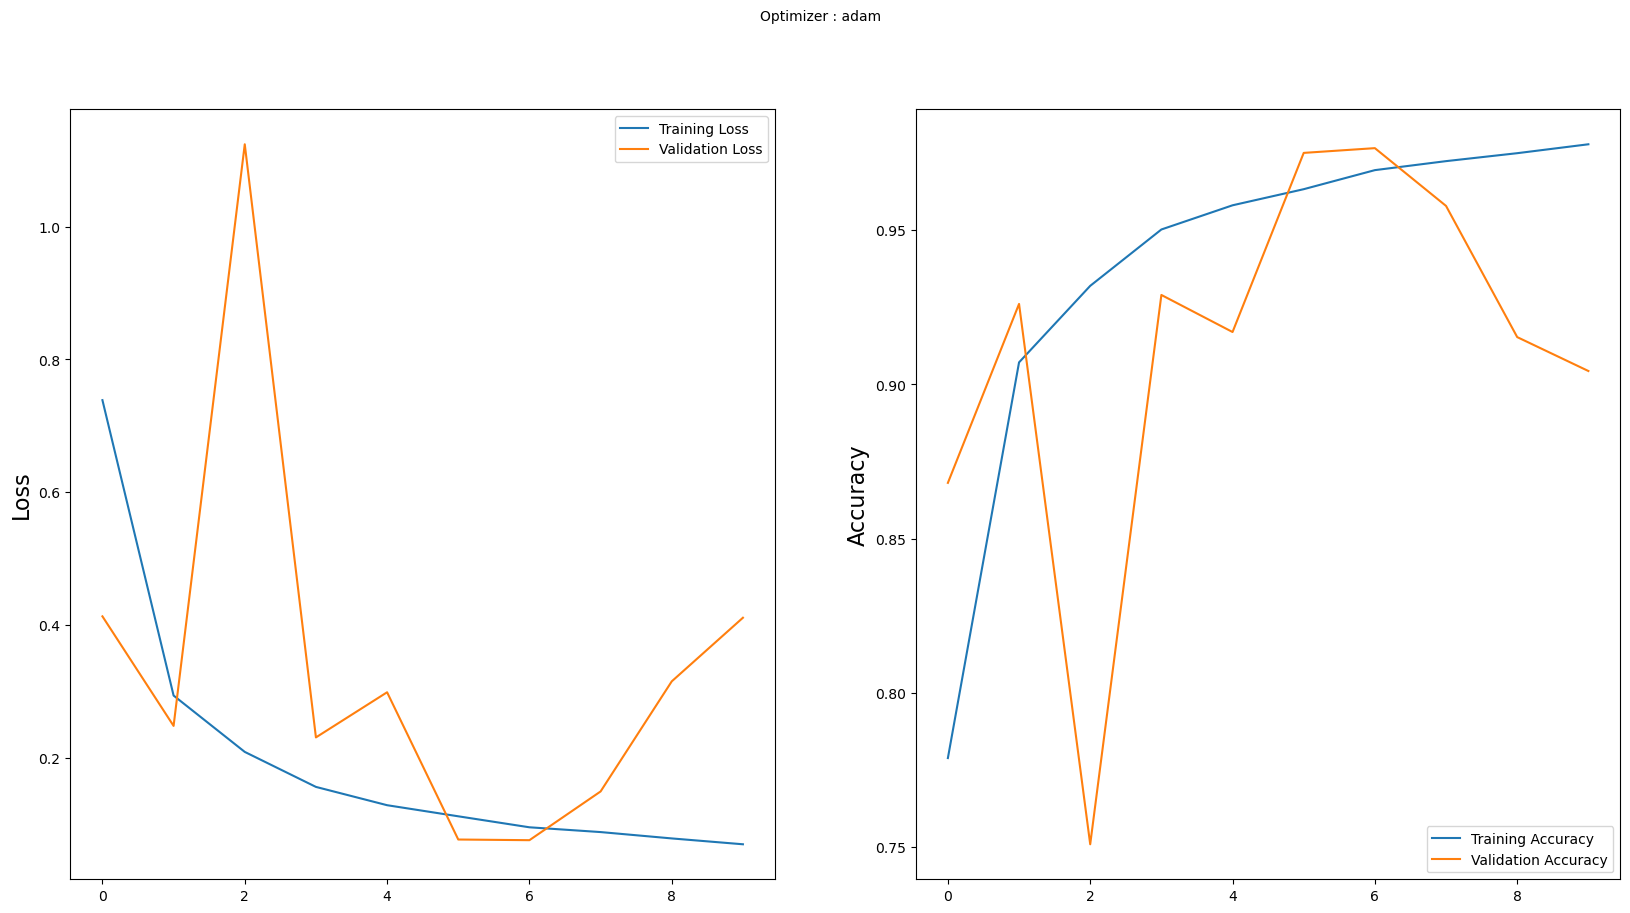

In [55]:
import matplotlib.pyplot as plt

x=hist9
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# Comparison

In [69]:
#creating dataframe
import pandas as pd
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                        'Precision': precision,
                        'Recall'   : recall,
                        'F1-Score': f1score,
                       
                      })

In [70]:
result

,ML Model,Accuracy,Precision,Recall,F1-Score
0,AlexNet,0.961,0.967,0.955,0.961
1,ResNet,0.981,0.981,0.980,0.981
2,TLMViT,0.994,0.995,0.993,0.994
3,VGG16,0.029,0.000,0.000,0.000
4,VGG19,0.029,0.000,0.000,0.000
5,Xception,0.995,0.995,0.991,0.993
6,InceptionV3,0.904,0.911,0.901,0.905


# FE

In [24]:
import numpy as np 
import matplotlib.pyplot as plt
import glob
import cv2

from keras.models import Model, Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from keras.layers import BatchNormalization
import os
import seaborn as sns

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [26]:
ML_Model1 = []
accuracy1 = []
precision1 = []
recall1 = []
f1score1 = []


#function to call for storing the results
def storeResults1(model, a,b,c,d):
    ML_Model1.append(model)
    accuracy1.append(round(a, 3))
    precision1.append(round(b, 3))
    recall1.append(round(c, 3))
    f1score1.append(round(d, 3))

In [27]:
SIZE = 128  #Resize images

#Capture training data and labels into respective lists
train_images = []
train_labels = [] 

In [28]:
for directory_path in glob.glob("plantvillagenew1/train/*"):
    label = directory_path.split("\\")[-1]
    print(label)
    for img_path in glob.glob(os.path.join(directory_path, "*.jpg")):
        print(img_path)
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)       
        img = cv2.resize(img, (SIZE, SIZE))
        img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        train_images.append(img)
        train_labels.append(label)

Apple___Apple_scab
output/train\Apple___Apple_scab\00075aa8-d81a-4184-8541-b692b78d398a___FREC_Scab 3335_270deg.JPG
output/train\Apple___Apple_scab\00075aa8-d81a-4184-8541-b692b78d398a___FREC_Scab 3335_90deg.JPG
output/train\Apple___Apple_scab\00075aa8-d81a-4184-8541-b692b78d398a___FREC_Scab 3335_new30degFlipLR.JPG
output/train\Apple___Apple_scab\0208f4eb-45a4-4399-904e-989ac2c6257c___FREC_Scab 3037_90deg.JPG
output/train\Apple___Apple_scab\023123cb-7b69-4c9f-a521-766d7c8543bb___FREC_Scab 3487.JPG
output/train\Apple___Apple_scab\023123cb-7b69-4c9f-a521-766d7c8543bb___FREC_Scab 3487_90deg.JPG
output/train\Apple___Apple_scab\0261a6e4-21f8-481a-8827-b674e6955644___FREC_Scab 3055.JPG
output/train\Apple___Apple_scab\0261a6e4-21f8-481a-8827-b674e6955644___FREC_Scab 3055_new30degFlipLR.JPG
output/train\Apple___Apple_scab\03354abb-aa1c-4f9d-a1ef-9f40505cd539___FREC_Scab 3355.JPG
output/train\Apple___Apple_scab\0340dc35-5215-48ab-8db7-06af99fcb358___FREC_Scab 2966_90deg.JPG
output/train\Apple__

output/train\Apple___Apple_scab\b84c8919-1f8c-4751-a759-e0ec84839020___FREC_Scab 3264_270deg.JPG
output/train\Apple___Apple_scab\b963d384-123e-48e5-ac66-a1e87f33ba0b___FREC_Scab 3021_90deg.JPG
output/train\Apple___Apple_scab\ba325c11-e91c-4f5e-9ae0-76f8f0bb24df___FREC_Scab 3523_new30degFlipLR.JPG
output/train\Apple___Apple_scab\bb495423-1617-447c-95cd-52ebabee1a59___FREC_Scab 3199_270deg.JPG
output/train\Apple___Apple_scab\bc7769cc-805e-42ef-bbcf-0c134ff03276___FREC_Scab 2909_new30degFlipLR.JPG
output/train\Apple___Apple_scab\bc93b0fd-568f-4969-9d2d-c94d5f340e7e___FREC_Scab 3357.JPG
output/train\Apple___Apple_scab\bca5ef0a-0555-4f76-9f9c-c01bee56b816___FREC_Scab 3200_90deg.JPG
output/train\Apple___Apple_scab\bdaae6b2-8ff5-4a4c-9286-a2393063cdaf___FREC_Scab 3491_270deg.JPG
output/train\Apple___Apple_scab\bdaae6b2-8ff5-4a4c-9286-a2393063cdaf___FREC_Scab 3491_new30degFlipLR.JPG
output/train\Apple___Apple_scab\be076652-b1bd-430c-a752-db525c1dfcfd___FREC_Scab 3367_90deg.JPG
output/train\App

output/train\Apple___Black_rot\74276bec-59f3-4bb6-b739-0b6ed819288c___JR_FrgE.S 2925_90deg.JPG
output/train\Apple___Black_rot\7504315d-b8fb-4b7d-a293-2e224968ab30___JR_FrgE.S 8697_new30degFlipLR.JPG
output/train\Apple___Black_rot\7558e6ff-8441-4ed8-b881-54288ab95441___JR_FrgE.S 2920_new30degFlipLR.JPG
output/train\Apple___Black_rot\75e9b8ed-e579-469c-96ec-d964fc7d4d90___JR_FrgE.S 8581.JPG
output/train\Apple___Black_rot\760ef647-ba10-4477-a388-105182a0c0e2___JR_FrgE.S 2895.JPG
output/train\Apple___Black_rot\760ef647-ba10-4477-a388-105182a0c0e2___JR_FrgE.S 2895_90deg.JPG
output/train\Apple___Black_rot\77843368-1495-4113-b865-83e381f0641e___JR_FrgE.S 8791.JPG
output/train\Apple___Black_rot\7add2958-0ee2-42e3-a99f-4b7a8e51db04___JR_FrgE.S 8745.JPG
output/train\Apple___Black_rot\7add2e39-6555-4d52-ad02-b1bb061db8e7___JR_FrgE.S 3039_90deg.JPG
output/train\Apple___Black_rot\7b4b37d4-fec6-4e52-8c88-a6e1e69aeeb2___JR_FrgE.S 8588.JPG
output/train\Apple___Black_rot\7c6d3ea5-7af7-411b-982d-8054c54

output/train\Apple___Cedar_apple_rust\3fb3806c-db88-491d-b9b0-191b3d5964cd___FREC_C.Rust 4130_newPixel25.JPG
output/train\Apple___Cedar_apple_rust\402aad30-3914-4227-a9b4-4d40a49fae72___FREC_C.Rust 0230_newGRR.JPG
output/train\Apple___Cedar_apple_rust\402aad30-3914-4227-a9b4-4d40a49fae72___FREC_C.Rust 0230_newPixel25.JPG
output/train\Apple___Cedar_apple_rust\4134586e-a00a-4c53-8f8d-c275ef0d5f5f___FREC_C.Rust 3676_180deg.JPG
output/train\Apple___Cedar_apple_rust\42bbd61a-bfa0-4adf-a064-407165f70ecf___FREC_C.Rust 4199_180deg.JPG
output/train\Apple___Cedar_apple_rust\43850a33-b2c2-4d67-aa90-685f8f76da3a___FREC_C.Rust 3664.JPG
output/train\Apple___Cedar_apple_rust\4485494e-e310-49b5-9ca8-73608ec4e83c___FREC_C.Rust 3631_180deg.JPG
output/train\Apple___Cedar_apple_rust\4485494e-e310-49b5-9ca8-73608ec4e83c___FREC_C.Rust 3631_270deg.JPG
output/train\Apple___Cedar_apple_rust\4485494e-e310-49b5-9ca8-73608ec4e83c___FREC_C.Rust 3631_90deg.JPG
output/train\Apple___Cedar_apple_rust\46597071-9826-4f7

output/train\Apple___healthy\2735c32b-b407-4714-b190-2b35d8e9a61f___RS_HL 8104.JPG
output/train\Apple___healthy\2768d40f-209f-4f71-a90a-a5f748fe299a___RS_HL 5938_flipTB.JPG
output/train\Apple___healthy\2836a80f-2aa7-46b1-8d64-0cf10037eb67___RS_HL 7268.JPG
output/train\Apple___healthy\28c298e3-0846-4372-a9ab-562f2ce7cf9d___RS_HL 5846.JPG
output/train\Apple___healthy\2b0d21b2-2320-4cb4-8d40-4684f0c91e55___RS_HL 7505.JPG
output/train\Apple___healthy\2dc5f050-21dd-4b81-a1cb-ef2a9f72f134___RS_HL 5694.JPG
output/train\Apple___healthy\30995ef5-ad2d-4949-b0e0-f98b074b4a96___RS_HL 7378_flipTB.JPG
output/train\Apple___healthy\313b7055-4346-4b7c-99fb-ada974f60486___RS_HL 6275.JPG
output/train\Apple___healthy\32b6be5f-6482-4bd2-876d-c2a518afed09___RS_HL 6163.JPG
output/train\Apple___healthy\336c4870-9f2f-4cdc-ba05-f9d27271ef07___RS_HL 7670.JPG
output/train\Apple___healthy\349251ed-2e99-4af9-b432-2a63202a0985___RS_HL 6120_flipTB.JPG
output/train\Apple___healthy\36321868-bd15-45bc-94f7-b86603f7460d_

...

output/train\Tomato___Spider_mites Two-spotted_spider_mite\5bad9c7d-db56-488a-9f62-6fe285b511a3___Com.G_SpM_FL 1439_180deg.JPG
output/train\Tomato___Spider_mites Two-spotted_spider_mite\5baec3fa-4a77-4bee-96b3-330696b48f8a___Com.G_SpM_FL 8658.JPG
output/train\Tomato___Spider_mites Two-spotted_spider_mite\5d218af0-e5cf-43b7-acce-de9f86baa690___Com.G_SpM_FL 9272_flipTB.JPG
output/train\Tomato___Spider_mites Two-spotted_spider_mite\5d41d1f6-6e1c-401c-9ac3-d81683ea1191___Com.G_SpM_FL 9030_flipTB.JPG
output/train\Tomato___Spider_mites Two-spotted_spider_mite\5dead4dc-bc58-4470-9d86-3d5cb6be14b7___Com.G_SpM_FL 1471_flipTB.JPG
output/train\Tomato___Spider_mites Two-spotted_spider_mite\5dfe90b9-9c33-4d29-bc96-c08dd5cf5d05___Com.G_SpM_FL 1185_flipTB.JPG
output/train\Tomato___Spider_mites Two-spotted_spider_mite\5e01fe8b-38c3-4de6-beee-50266519f226___Com.G_SpM_FL 9376.JPG
output/train\Tomato___Spider_mites Two-spotted_spider_mite\5e4d96fa-4eec-4d95-a3a2-6d6afbc5a004___Com.G_SpM_FL 9496.JPG
outpu

output/train\Tomato___Target_Spot\1f778f17-eacb-4d7a-bf34-041955ebff8f___Com.G_TgS_FL 0694_newPixel25.JPG
output/train\Tomato___Target_Spot\22beb2c0-f830-421b-99b9-eaa0519b1667___Com.G_TgS_FL 0739.JPG
output/train\Tomato___Target_Spot\2334031d-35e6-4e99-bfee-e21c5fa1a75f___Com.G_TgS_FL 8334.JPG
output/train\Tomato___Target_Spot\290ea84a-2458-4291-8065-644c5a826935___Com.G_TgS_FL 0039.JPG
output/train\Tomato___Target_Spot\2a1fa2a0-b6ab-4c9b-984f-ea4108087568___Com.G_TgS_FL 8225.JPG
output/train\Tomato___Target_Spot\2a71aaa1-bbbc-4d44-a8b6-8ef1f0ebd8ff___Com.G_TgS_FL 1102_180deg.JPG
output/train\Tomato___Target_Spot\2a71aaa1-bbbc-4d44-a8b6-8ef1f0ebd8ff___Com.G_TgS_FL 1102_flipTB.JPG
output/train\Tomato___Target_Spot\2a955c94-cc01-416d-ae86-6ea06af3c253___Com.G_TgS_FL 8056.JPG
output/train\Tomato___Target_Spot\2b2c841a-f3e8-4861-83d4-c00eaace0049___Com.G_TgS_FL 9897.JPG
output/train\Tomato___Target_Spot\2c93d540-be61-4546-9cbc-74c776f19379___Com.G_TgS_FL 0690_newPixel25.JPG
output/train\T

output/train\Tomato___Tomato_mosaic_virus\006e354b-c054-4b72-a83c-e3feb038942e___PSU_CG 2330_newPixel25.JPG
output/train\Tomato___Tomato_mosaic_virus\00c07a77-15e6-4815-92d4-8d1e1afb7f3c___PSU_CG 2052_180deg.JPG
output/train\Tomato___Tomato_mosaic_virus\021accd9-bbb2-4777-8f94-93295e6de49e___PSU_CG 2075_90deg.JPG
output/train\Tomato___Tomato_mosaic_virus\021accd9-bbb2-4777-8f94-93295e6de49e___PSU_CG 2075_newPixel25.JPG
output/train\Tomato___Tomato_mosaic_virus\02cb8c4e-4542-4020-bb46-025de54d97ae___PSU_CG 2098_90deg.JPG
output/train\Tomato___Tomato_mosaic_virus\03b6acc7-41a6-4670-b47c-bef6d4baea18___PSU_CG 2363_180deg.JPG
output/train\Tomato___Tomato_mosaic_virus\03b6acc7-41a6-4670-b47c-bef6d4baea18___PSU_CG 2363_newPixel25.JPG
output/train\Tomato___Tomato_mosaic_virus\046a2559-23b4-4018-a3db-337347ceb391___PSU_CG 2321_new30degFlipLR.JPG
output/train\Tomato___Tomato_mosaic_virus\05910684-8466-4472-b520-b6f90bfc0d01___PSU_CG 2076_90deg.JPG
output/train\Tomato___Tomato_mosaic_virus\05910

output/train\Tomato___Tomato_mosaic_virus\c1ca36c4-bffc-494d-9199-0753d7319bce___PSU_CG 2357.JPG
output/train\Tomato___Tomato_mosaic_virus\c1ff629a-8390-43a4-88ed-86e462d688a7___PSU_CG 2083_270deg.JPG
output/train\Tomato___Tomato_mosaic_virus\c1ff629a-8390-43a4-88ed-86e462d688a7___PSU_CG 2083_newPixel25.JPG
output/train\Tomato___Tomato_mosaic_virus\c44f307f-dd40-495d-abfa-e2f68dc31ff6___PSU_CG 2312_180deg.JPG
output/train\Tomato___Tomato_mosaic_virus\c5132603-ce86-45c0-b9f9-d35c07f4057f___PSU_CG 2256_90deg.JPG
output/train\Tomato___Tomato_mosaic_virus\c668017b-5c87-4f2e-90ab-021b81f48b1b___PSU_CG 2272_270deg.JPG
output/train\Tomato___Tomato_mosaic_virus\c7f8e876-66c2-4014-82a4-47d4556bfb7d___PSU_CG 2418_90deg.JPG
output/train\Tomato___Tomato_mosaic_virus\c9bbf37c-d34f-41b7-9134-e3b81f4e739e___PSU_CG 2145.JPG
output/train\Tomato___Tomato_mosaic_virus\c9bbf37c-d34f-41b7-9134-e3b81f4e739e___PSU_CG 2145_270deg.JPG
output/train\Tomato___Tomato_mosaic_virus\cfd8a28f-7af7-4102-b848-0b6d1b2c60

output/train\Tomato___Tomato_Yellow_Leaf_Curl_Virus\cc2d723c-a4c2-4526-8943-122ec23ca493___UF.GRC_YLCV_Lab 03037.JPG
output/train\Tomato___Tomato_Yellow_Leaf_Curl_Virus\cc3769bf-69f3-4ff3-b2bb-dc9ec504fbfb___YLCV_NREC 2609.JPG
output/train\Tomato___Tomato_Yellow_Leaf_Curl_Virus\cd296a5b-4bd0-468f-836e-014311b2be82___UF.GRC_YLCV_Lab 01442.JPG
output/train\Tomato___Tomato_Yellow_Leaf_Curl_Virus\cd37cbce-e141-40a5-8af6-8fa6790c7ed3___UF.GRC_YLCV_Lab 02128.JPG
output/train\Tomato___Tomato_Yellow_Leaf_Curl_Virus\cde91c06-5346-4b7e-807e-afa22a42a7cb___UF.GRC_YLCV_Lab 01402.JPG
output/train\Tomato___Tomato_Yellow_Leaf_Curl_Virus\cf311413-7541-4c1a-a45b-92f37a7c7726___UF.GRC_YLCV_Lab 09571.JPG
output/train\Tomato___Tomato_Yellow_Leaf_Curl_Virus\cf968b6f-7659-4e03-afa6-6fb3f57f47b0___UF.GRC_YLCV_Lab 08498.JPG
output/train\Tomato___Tomato_Yellow_Leaf_Curl_Virus\cfb78471-bb1f-4ff1-8770-31471af27d37___UF.GRC_YLCV_Lab 03360.JPG
output/train\Tomato___Tomato_Yellow_Leaf_Curl_Virus\d0100773-6346-4e0c-

In [29]:
#Convert lists to arrays        
train_images = np.array(train_images)
train_labels = np.array(train_labels)

In [30]:
# Capture test/validation data and labels into respective lists

test_images = []
test_labels = [] 
for directory_path in glob.glob("plantvillagenew1/val/*"):
    fruit_label = directory_path.split("\\")[-1]
    for img_path in glob.glob(os.path.join(directory_path, "*.jpg")):
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        img = cv2.resize(img, (SIZE, SIZE))
        img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        test_images.append(img)
        test_labels.append(fruit_label)

In [31]:
#Convert lists to arrays                
test_images = np.array(test_images)
test_labels = np.array(test_labels)

In [32]:
#Encode labels from text to integers.
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
le.fit(test_labels)
test_labels_encoded = le.transform(test_labels)
le.fit(train_labels)
train_labels_encoded = le.transform(train_labels)

In [33]:
#Split data into test and train datasets (already split but assigning to meaningful convention)
x_train, y_train, x_test, y_test = train_images, train_labels_encoded, test_images, test_labels_encoded

###################################################################
# Normalize pixel values to between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0


In [34]:
#One hot encode y values for neural network. 
from tensorflow.keras.utils import to_categorical
y_train_one_hot = to_categorical(y_train)
y_test_one_hot = to_categorical(y_test)

In [35]:
from tensorflow.keras.models import load_model

In [36]:
model_path2 = 'alex.h5' # load .h5 Model
model_fe = load_model(model_path2, custom_objects={'f1_score' : f1_m, 'precision_score' : precision_m, 'recall_score' : recall_m}, compile=False)

In [37]:
#Now, let us use features from convolutional network for RF
feature_extractor= model_fe.predict(x_train)

384/384 [==============================] - 2s 4ms/step


In [38]:
features = feature_extractor.reshape(feature_extractor.shape[0], -1)

X_train_feature = features

In [39]:
X_test_feature = model_fe.predict(x_test)
X_test_features = X_test_feature.reshape(X_test_feature.shape[0], -1)

166/166 [==============================] - 1s 4ms/step


# AlexNet - MLP

In [41]:
from sklearn.neural_network import MLPClassifier
mlp_model = MLPClassifier(random_state=1, max_iter=300)
mlp_model.fit(X_train_feature, y_train) #For sklearn no one hot encoding

prediction_mlp = mlp_model.predict(X_test_features)
#Inverse le transform to get original label back. 
prediction_mlp = le.inverse_transform(prediction_mlp)

mlp_acc_cnn = accuracy_score(test_labels, prediction_mlp)
mlp_prec_cnn = precision_score(test_labels, prediction_mlp,average='weighted')
mlp_rec_cnn = recall_score(test_labels, prediction_mlp,average='weighted')
mlp_f1_cnn = f1_score(test_labels, prediction_mlp,average='weighted')

In [42]:
storeResults1('AlexNet-MLP',mlp_acc_cnn,mlp_prec_cnn,mlp_rec_cnn,mlp_f1_cnn)

# Voting Classifier

In [43]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
clf1 = DecisionTreeClassifier()
clf2 = RandomForestClassifier()

eclf1 = VotingClassifier(estimators=[('dt', clf1),('rf', clf2)], voting='soft')
eclf1.fit(X_train_feature, y_train)

prediction_vot = eclf1.predict(X_test_features)
#Inverse le transform to get original label back. 
prediction_vot = le.inverse_transform(prediction_vot)

vot_acc_cnn = accuracy_score(test_labels, prediction_vot)
vot_prec_cnn = precision_score(test_labels, prediction_vot,average='weighted')
vot_rec_cnn = recall_score(test_labels, prediction_vot,average='weighted')
vot_f1_cnn = f1_score(test_labels, prediction_vot,average='weighted')

print(vot_acc_cnn,vot_prec_cnn,vot_rec_cnn,vot_f1_cnn)

0.9812783661119516 0.9813753321670889 0.9812783661119516 0.9812503217486548


In [44]:
storeResults1('AlexNet-Voting',vot_acc_cnn,vot_prec_cnn,vot_rec_cnn,vot_f1_cnn)

# ResNet - FE

In [45]:
model_path2 = 'resnet.h5' # load .h5 Model
model_fe = load_model(model_path2, custom_objects={'f1_score' : f1_m, 'precision_score' : precision_m, 'recall_score' : recall_m}, compile=False)

In [46]:
#Now, let us use features from convolutional network for RF
feature_extractor= model_fe.predict(x_train)
features = feature_extractor.reshape(feature_extractor.shape[0], -1)

X_train_feature = features

384/384 [==============================] - 5s 10ms/step


In [47]:
X_test_feature = model_fe.predict(x_test)
X_test_features = X_test_feature.reshape(X_test_feature.shape[0], -1)

166/166 [==============================] - 2s 10ms/step


# MLP

In [49]:
from sklearn.neural_network import MLPClassifier
mlp_model = MLPClassifier(random_state=1, max_iter=300)
mlp_model.fit(X_train_feature, y_train) #For sklearn no one hot encoding

prediction_mlp = mlp_model.predict(X_test_features)
#Inverse le transform to get original label back. 
prediction_mlp = le.inverse_transform(prediction_mlp)

mlp_acc_cnn = accuracy_score(test_labels, prediction_mlp)
mlp_prec_cnn = precision_score(test_labels, prediction_mlp,average='weighted')
mlp_rec_cnn = recall_score(test_labels, prediction_mlp,average='weighted')
mlp_f1_cnn = f1_score(test_labels, prediction_mlp,average='weighted')

In [50]:
storeResults1('ResNet-MLP',mlp_acc_cnn,mlp_prec_cnn,mlp_rec_cnn,mlp_f1_cnn)

# Voting

In [51]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
clf1 = DecisionTreeClassifier()
clf2 = RandomForestClassifier()

eclf1 = VotingClassifier(estimators=[('dt', clf1),('rf', clf2)], voting='soft')
eclf1.fit(X_train_feature, y_train)

prediction_vot = eclf1.predict(X_test_features)
#Inverse le transform to get original label back. 
prediction_vot = le.inverse_transform(prediction_vot)

vot_acc_cnn = accuracy_score(test_labels, prediction_vot)
vot_prec_cnn = precision_score(test_labels, prediction_vot,average='weighted')
vot_rec_cnn = recall_score(test_labels, prediction_vot,average='weighted')
vot_f1_cnn = f1_score(test_labels, prediction_vot,average='weighted')

print(vot_acc_cnn,vot_prec_cnn,vot_rec_cnn,vot_f1_cnn)

0.9807110438729199 0.9809637250350136 0.9807110438729199 0.9807365543516522


In [52]:
storeResults1('ResNet-Voting',vot_acc_cnn,vot_prec_cnn,vot_rec_cnn,vot_f1_cnn)

# TLMViT

In [53]:
model_path2 = 'vit.h5' # load .h5 Model
model_fe = load_model(model_path2, custom_objects={'f1_score' : f1_m, 'precision_score' : precision_m, 'recall_score' : recall_m}, compile=False)

In [54]:
#Now, let us use features from convolutional network for RF
feature_extractor= model_fe.predict(x_train)

features = feature_extractor.reshape(feature_extractor.shape[0], -1)

X_train_feature = features

384/384 [==============================] - 17s 37ms/step


In [55]:
X_test_feature = model_fe.predict(x_test)
X_test_features = X_test_feature.reshape(X_test_feature.shape[0], -1)

166/166 [==============================] - 6s 36ms/step


# MLP

In [56]:
from sklearn.neural_network import MLPClassifier
mlp_model = MLPClassifier(random_state=1, max_iter=300)
mlp_model.fit(X_train_feature, y_train) #For sklearn no one hot encoding

prediction_mlp = mlp_model.predict(X_test_features)
#Inverse le transform to get original label back. 
prediction_mlp = le.inverse_transform(prediction_mlp)

mlp_acc_cnn = accuracy_score(test_labels, prediction_mlp)
mlp_prec_cnn = precision_score(test_labels, prediction_mlp,average='weighted')
mlp_rec_cnn = recall_score(test_labels, prediction_mlp,average='weighted')
mlp_f1_cnn = f1_score(test_labels, prediction_mlp,average='weighted')

storeResults1('TLMViT-MLP',mlp_acc_cnn,mlp_prec_cnn,mlp_rec_cnn,mlp_f1_cnn)

# Voting 

In [57]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
clf1 = DecisionTreeClassifier()
clf2 = RandomForestClassifier()

eclf1 = VotingClassifier(estimators=[('dt', clf1),('rf', clf2)], voting='soft')
eclf1.fit(X_train_feature, y_train)

prediction_vot = eclf1.predict(X_test_features)
#Inverse le transform to get original label back. 
prediction_vot = le.inverse_transform(prediction_vot)

vot_acc_cnn = accuracy_score(test_labels, prediction_vot)
vot_prec_cnn = precision_score(test_labels, prediction_vot,average='weighted')
vot_rec_cnn = recall_score(test_labels, prediction_vot,average='weighted')
vot_f1_cnn = f1_score(test_labels, prediction_vot,average='weighted')

storeResults1('TLMViT-Voting',vot_acc_cnn,vot_prec_cnn,vot_rec_cnn,vot_f1_cnn)

# VGG16

In [58]:
model_path2 = 'vgg16.h5' # load .h5 Model
model_fe = load_model(model_path2, custom_objects={'f1_score' : f1_m, 'precision_score' : precision_m, 'recall_score' : recall_m}, compile=False)

In [59]:
#Now, let us use features from convolutional network for RF
feature_extractor= model_fe.predict(x_train)

features = feature_extractor.reshape(feature_extractor.shape[0], -1)

X_train_feature = features

384/384 [==============================] - 4s 8ms/step


In [60]:
X_test_feature = model_fe.predict(x_test)
X_test_features = X_test_feature.reshape(X_test_feature.shape[0], -1)

166/166 [==============================] - 1s 8ms/step


# MLP

In [61]:
from sklearn.neural_network import MLPClassifier
mlp_model = MLPClassifier(random_state=1, max_iter=300)
mlp_model.fit(X_train_feature, y_train) #For sklearn no one hot encoding

prediction_mlp = mlp_model.predict(X_test_features)
#Inverse le transform to get original label back. 
prediction_mlp = le.inverse_transform(prediction_mlp)

mlp_acc_cnn = accuracy_score(test_labels, prediction_mlp)
mlp_prec_cnn = precision_score(test_labels, prediction_mlp,average='weighted')
mlp_rec_cnn = recall_score(test_labels, prediction_mlp,average='weighted')
mlp_f1_cnn = f1_score(test_labels, prediction_mlp,average='weighted')

print(mlp_acc_cnn,mlp_prec_cnn,mlp_rec_cnn,mlp_f1_cnn)

0.028744326777609682 0.0008262363218980091 0.028744326777609682 0.001606300614042894


In [62]:
storeResults1('VGG16-MLP',mlp_acc_cnn,mlp_prec_cnn,mlp_rec_cnn,mlp_f1_cnn)

# Voting

In [63]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
clf1 = DecisionTreeClassifier()
clf2 = RandomForestClassifier()

eclf1 = VotingClassifier(estimators=[('dt', clf1),('rf', clf2)], voting='soft')
eclf1.fit(X_train_feature, y_train)

prediction_vot = eclf1.predict(X_test_features)
#Inverse le transform to get original label back. 
prediction_vot = le.inverse_transform(prediction_vot)

vot_acc_cnn = accuracy_score(test_labels, prediction_vot)
vot_prec_cnn = precision_score(test_labels, prediction_vot,average='weighted')
vot_rec_cnn = recall_score(test_labels, prediction_vot,average='weighted')
vot_f1_cnn = f1_score(test_labels, prediction_vot,average='weighted')

print(vot_acc_cnn,vot_prec_cnn,vot_rec_cnn,vot_f1_cnn)

0.028744326777609682 0.0008262363218980091 0.028744326777609682 0.001606300614042894


In [64]:
storeResults1('VGG16-Voting',vot_acc_cnn,vot_prec_cnn,vot_rec_cnn,vot_f1_cnn)

# VGG19

In [65]:
model_path2 = 'vgg19.h5' # load .h5 Model
model_fe = load_model(model_path2, custom_objects={'f1_score' : f1_m, 'precision_score' : precision_m, 'recall_score' : recall_m}, compile=False)

In [66]:
#Now, let us use features from convolutional network for RF
feature_extractor= model_fe.predict(x_train)

features = feature_extractor.reshape(feature_extractor.shape[0], -1)

X_train_feature = features

384/384 [==============================] - 3s 8ms/step


In [67]:
X_test_feature = model_fe.predict(x_test)
X_test_features = X_test_feature.reshape(X_test_feature.shape[0], -1)

166/166 [==============================] - 1s 8ms/step


# MLP

In [68]:
from sklearn.neural_network import MLPClassifier
mlp_model = MLPClassifier(random_state=1, max_iter=300)
mlp_model.fit(X_train_feature, y_train) #For sklearn no one hot encoding

prediction_mlp = mlp_model.predict(X_test_features)
#Inverse le transform to get original label back. 
prediction_mlp = le.inverse_transform(prediction_mlp)

mlp_acc_cnn = accuracy_score(test_labels, prediction_mlp)
mlp_prec_cnn = precision_score(test_labels, prediction_mlp,average='weighted')
mlp_rec_cnn = recall_score(test_labels, prediction_mlp,average='weighted')
mlp_f1_cnn = f1_score(test_labels, prediction_mlp,average='weighted')

print(mlp_acc_cnn,mlp_prec_cnn,mlp_rec_cnn,mlp_f1_cnn)

0.028744326777609682 0.0008262363218980091 0.028744326777609682 0.001606300614042894


In [69]:
storeResults1('VGG19-MLP',mlp_acc_cnn,mlp_prec_cnn,mlp_rec_cnn,mlp_f1_cnn)

# Voting

In [70]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
clf1 = DecisionTreeClassifier()
clf2 = RandomForestClassifier()

eclf1 = VotingClassifier(estimators=[('dt', clf1),('rf', clf2)], voting='soft')
eclf1.fit(X_train_feature, y_train)

prediction_vot = eclf1.predict(X_test_features)
#Inverse le transform to get original label back. 
prediction_vot = le.inverse_transform(prediction_vot)

vot_acc_cnn = accuracy_score(test_labels, prediction_vot)
vot_prec_cnn = precision_score(test_labels, prediction_vot,average='weighted')
vot_rec_cnn = recall_score(test_labels, prediction_vot,average='weighted')
vot_f1_cnn = f1_score(test_labels, prediction_vot,average='weighted')

print(vot_acc_cnn,vot_prec_cnn,vot_rec_cnn,vot_f1_cnn)

0.028744326777609682 0.0008262363218980091 0.028744326777609682 0.001606300614042894


In [71]:
storeResults1('VGG19-Voting',vot_acc_cnn,vot_prec_cnn,vot_rec_cnn,vot_f1_cnn)

# InceptionV3

In [72]:
model_path2 = 'incep.h5' # load .h5 Model
model_fe = load_model(model_path2, custom_objects={'f1_score' : f1_m, 'precision_score' : precision_m, 'recall_score' : recall_m}, compile=False)

In [73]:
#Now, let us use features from convolutional network for RF
feature_extractor= model_fe.predict(x_train)

features = feature_extractor.reshape(feature_extractor.shape[0], -1)

X_train_feature = features

384/384 [==============================] - 7s 15ms/step


In [74]:
X_test_feature = model_fe.predict(x_test)
X_test_features = X_test_feature.reshape(X_test_feature.shape[0], -1)

166/166 [==============================] - 2s 15ms/step


# MLP

In [75]:
from sklearn.neural_network import MLPClassifier
mlp_model = MLPClassifier(random_state=1, max_iter=300)
mlp_model.fit(X_train_feature, y_train) #For sklearn no one hot encoding

prediction_mlp = mlp_model.predict(X_test_features)
#Inverse le transform to get original label back. 
prediction_mlp = le.inverse_transform(prediction_mlp)

mlp_acc_cnn = accuracy_score(test_labels, prediction_mlp)
mlp_prec_cnn = precision_score(test_labels, prediction_mlp,average='weighted')
mlp_rec_cnn = recall_score(test_labels, prediction_mlp,average='weighted')
mlp_f1_cnn = f1_score(test_labels, prediction_mlp,average='weighted')

storeResults1('InceptionV3-MLP',mlp_acc_cnn,mlp_prec_cnn,mlp_rec_cnn,mlp_f1_cnn)

# Voting

In [76]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
clf1 = DecisionTreeClassifier()
clf2 = RandomForestClassifier()

eclf1 = VotingClassifier(estimators=[('dt', clf1),('rf', clf2)], voting='soft')
eclf1.fit(X_train_feature, y_train)

prediction_vot = eclf1.predict(X_test_features)
#Inverse le transform to get original label back. 
prediction_vot = le.inverse_transform(prediction_vot)

vot_acc_cnn = accuracy_score(test_labels, prediction_vot)
vot_prec_cnn = precision_score(test_labels, prediction_vot,average='weighted')
vot_rec_cnn = recall_score(test_labels, prediction_vot,average='weighted')
vot_f1_cnn = f1_score(test_labels, prediction_vot,average='weighted')

storeResults1('InceptionV3-Voting',vot_acc_cnn,vot_prec_cnn,vot_rec_cnn,vot_f1_cnn)

# Xception

In [77]:
model_path2 = 'xce.h5' # load .h5 Model
model_fe = load_model(model_path2, custom_objects={'f1_score' : f1_m, 'precision_score' : precision_m, 'recall_score' : recall_m}, compile=False)

In [78]:
#Now, let us use features from convolutional network for RF
feature_extractor= model_fe.predict(x_train)

features = feature_extractor.reshape(feature_extractor.shape[0], -1)

X_train_feature = features

384/384 [==============================] - 4s 7ms/step


In [79]:
X_test_feature = model_fe.predict(x_test)
X_test_features = X_test_feature.reshape(X_test_feature.shape[0], -1)

166/166 [==============================] - 1s 7ms/step


# MLP

In [80]:
from sklearn.neural_network import MLPClassifier
mlp_model = MLPClassifier(random_state=1, max_iter=300)
mlp_model.fit(X_train_feature, y_train) #For sklearn no one hot encoding

prediction_mlp = mlp_model.predict(X_test_features)
#Inverse le transform to get original label back. 
prediction_mlp = le.inverse_transform(prediction_mlp)

mlp_acc_cnn = accuracy_score(test_labels, prediction_mlp)
mlp_prec_cnn = precision_score(test_labels, prediction_mlp,average='weighted')
mlp_rec_cnn = recall_score(test_labels, prediction_mlp,average='weighted')
mlp_f1_cnn = f1_score(test_labels, prediction_mlp,average='weighted')

storeResults1('Xception-MLP',mlp_acc_cnn,mlp_prec_cnn,mlp_rec_cnn,mlp_f1_cnn)

# Voting

In [81]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
clf1 = DecisionTreeClassifier()
clf2 = RandomForestClassifier()

eclf1 = VotingClassifier(estimators=[('dt', clf1),('rf', clf2)], voting='soft')
eclf1.fit(X_train_feature, y_train)

prediction_vot = eclf1.predict(X_test_features)
#Inverse le transform to get original label back. 
prediction_vot = le.inverse_transform(prediction_vot)

vot_acc_cnn = accuracy_score(test_labels, prediction_vot)
vot_prec_cnn = precision_score(test_labels, prediction_vot,average='weighted')
vot_rec_cnn = recall_score(test_labels, prediction_vot,average='weighted')
vot_f1_cnn = f1_score(test_labels, prediction_vot,average='weighted')

storeResults1('Xception-Voting',vot_acc_cnn,vot_prec_cnn,vot_rec_cnn,vot_f1_cnn)

# Comparison

In [82]:
#creating dataframe
import pandas as pd
result = pd.DataFrame({ 'ML Model' : ML_Model1,
                        'Accuracy' : accuracy1,
                        'Precision': precision1,
                        'Recall'   : recall1,
                        'F1-Score': f1score1,
                       
                      })

In [83]:
result

,ML Model,Accuracy,Precision,Recall,F1-Score
0,AlexNet-MLP,0.987,0.987,0.987,0.987
1,AlexNet-Voting,0.981,0.981,0.981,0.981
2,ResNet-MLP,0.984,0.984,0.984,0.984
3,ResNet-Voting,0.981,0.981,0.981,0.981
4,TLMViT-MLP,0.958,0.958,0.958,0.957
5,TLMViT-Voting,0.944,0.944,0.944,0.944
6,VGG16-MLP,0.029,0.001,0.029,0.002
7,VGG16-Voting,0.029,0.001,0.029,0.002
8,VGG19-MLP,0.029,0.001,0.029,0.002
9,VGG19-Voting,0.029,0.001,0.029,0.002


# Graph

# DL

In [90]:
classifier = ML_Model
y_pos = np.arange(len(classifier))

# Accuracy

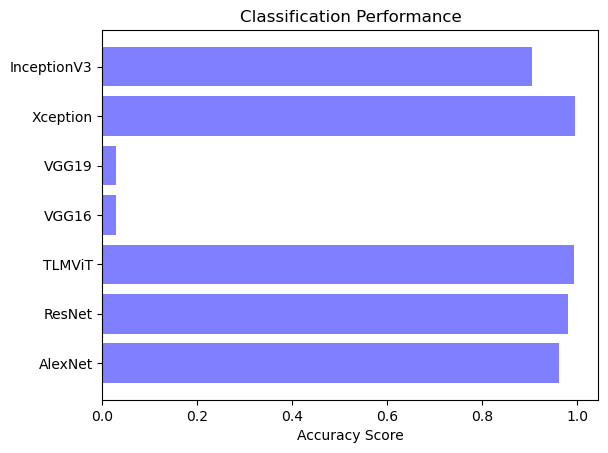

In [91]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, accuracy, align='center', alpha=0.5,color='blue')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Accuracy Score')
plt2.title('Classification Performance')
plt2.show()

# Precision

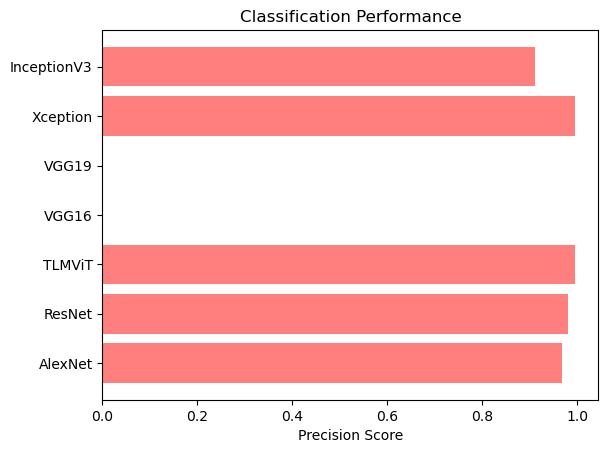

In [92]:
plt2.barh(y_pos, precision, align='center', alpha=0.5,color='red')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Precision Score')
plt2.title('Classification Performance')
plt2.show()

# Recall

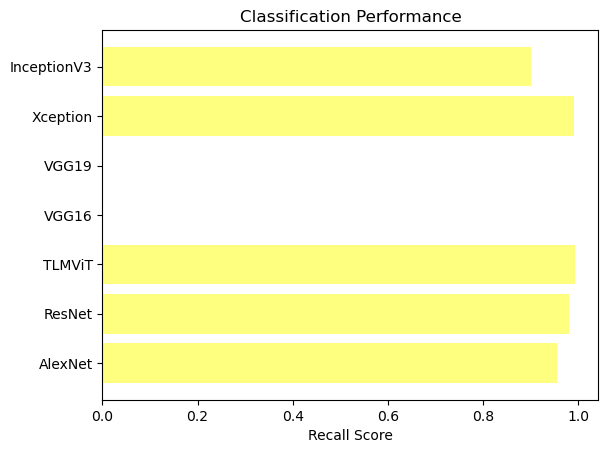

In [93]:
plt2.barh(y_pos, recall, align='center', alpha=0.5,color='yellow')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Recall Score')
plt2.title('Classification Performance')
plt2.show()

# F1 Score

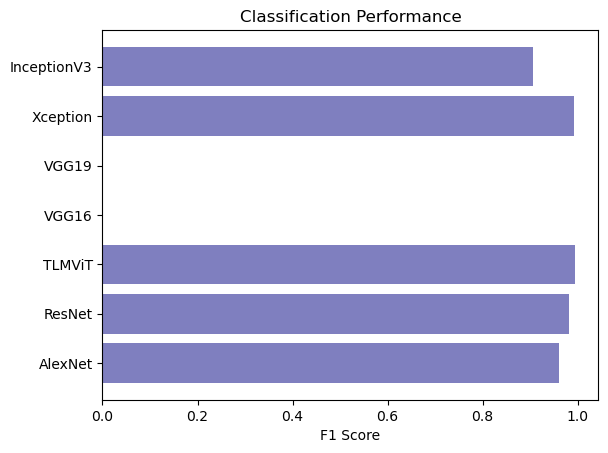

In [94]:
plt2.barh(y_pos, f1score, align='center', alpha=0.5,color='navy')
plt2.yticks(y_pos, classifier)
plt2.xlabel('F1 Score')
plt2.title('Classification Performance')
plt2.show()

# Feature Extraction

In [84]:
classifier = ML_Model1
y_pos = np.arange(len(classifier))

# Accuracy

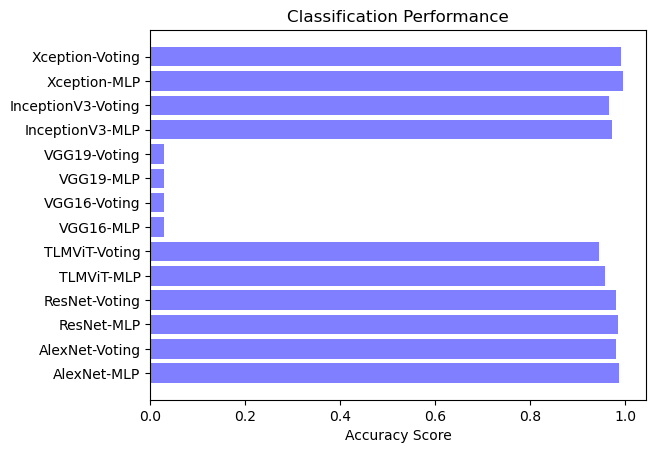

In [85]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, accuracy1, align='center', alpha=0.5,color='blue')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Accuracy Score')
plt2.title('Classification Performance')
plt2.show()

# Precision

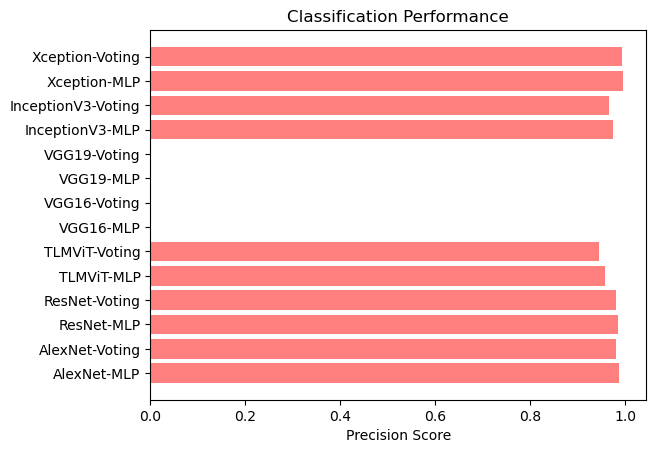

In [86]:
plt2.barh(y_pos, precision1, align='center', alpha=0.5,color='red')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Precision Score')
plt2.title('Classification Performance')
plt2.show()

# Recall

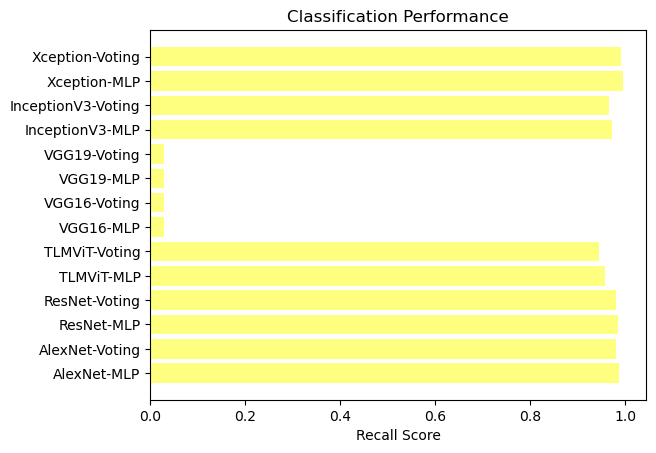

In [87]:
plt2.barh(y_pos, recall1, align='center', alpha=0.5,color='yellow')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Recall Score')
plt2.title('Classification Performance')
plt2.show()

# F1 Score

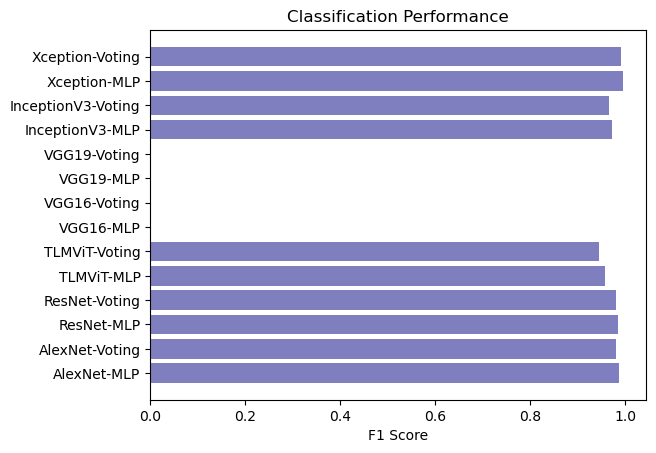

In [88]:
plt2.barh(y_pos, f1score1, align='center', alpha=0.5,color='navy')
plt2.yticks(y_pos, classifier)
plt2.xlabel('F1 Score')
plt2.title('Classification Performance')
plt2.show()